In [1]:
import numpy as np
import matplotlib.pyplot as plt
 
from sklearn.svm import SVR, SVC
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel, DotProduct
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import norm, rankdata
from scipy.optimize import minimize, brentq
from scipy.spatial.distance import cdist
from scipy.stats.qmc import LatinHypercube
from sklearn.base import clone

from sklearn.preprocessing import PowerTransformer
 
from skopt.sampler import Lhs
from skopt.space import Space
 
import shap
import torch
import torch.nn as nn
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Helper Functions

In [2]:
def compute_ucb(mu, sigma, kappa=2.5):
    return mu + kappa * sigma
 
def compute_ei(mu, sigma, f_best, xi=0.01):
    z = (mu - f_best - xi) / (sigma + 1e-9)
    ei = (mu - f_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma == 0] = 0
    return ei
 
def format_query(point, decimals=6):
    return '-'.join([f'{x:.{decimals}f}' for x in point])
 
def thompson_sample(gp, candidates, n_samples=10, subsample=500):
    idx = np.random.choice(len(candidates), size=min(subsample, len(candidates)), replace=False)
    sub = candidates[idx]
    samples = gp.sample_y(sub, n_samples=n_samples, random_state=42)
    best_sub_idx = np.argmax(samples.mean(axis=1))
    return idx[best_sub_idx]
 
# MC dropout prediction 
# model must be in train() mode so dropout stays active during prediction
def mc_predict(model, X_tensor, n_passes=50):
    model.train()
    preds = torch.stack([model(X_tensor).squeeze() for _ in range(n_passes)])
    return preds.mean(dim=0).detach().numpy(), preds.std(dim=0).detach().numpy()

# Function 1 - week 12

Function 1 - Week 12

All points (sorted by piecewise-scaled value):
  [0.624182 0.616547] --> output: 1.347e+00 --> scaled: 9.9789
  [0.62214  0.642261] --> output: 1.144e+00 --> scaled: 8.7116
  [0.647707 0.639762] --> output: 5.894e-01 --> scaled: 5.2461
  [0.603501 0.653629] --> output: 7.759e-02 --> scaled: 2.0474
  [0.461537 0.459084] --> output: -1.688e-05 --> scaled: 1.0538
  [0.694651 0.629916] --> output: -1.607e-03 --> scaled: 1.0323
  [0.65011406 0.68152635] --> output: -3.606e-03 --> scaled: 1.0053
  [0.68341817 0.86105746] --> output: 2.535e-40 --> scaled: 0.0000
  [0.57432921 0.8798981 ] --> output: 1.033e-46 --> scaled: 0.0000
  [0.73102363 0.73299988] --> output: 7.711e-16 --> scaled: 0.0000
  [0.84035342 0.26473161] --> output: 3.342e-124 --> scaled: 0.0000
  [0.41043714 0.1475543 ] --> output: -2.159e-54 --> scaled: 0.0000
  [0.31269116 0.07872278] --> output: -2.089e-91 --> scaled: 0.0000
  [0.959184 0.836735] --> output: -5.910e-107 --> scaled: 0.0000
  [0.08250725

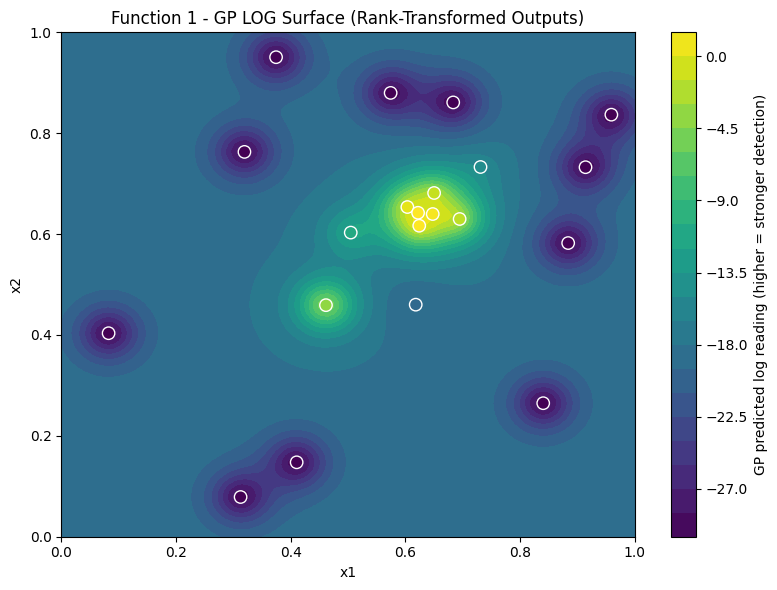

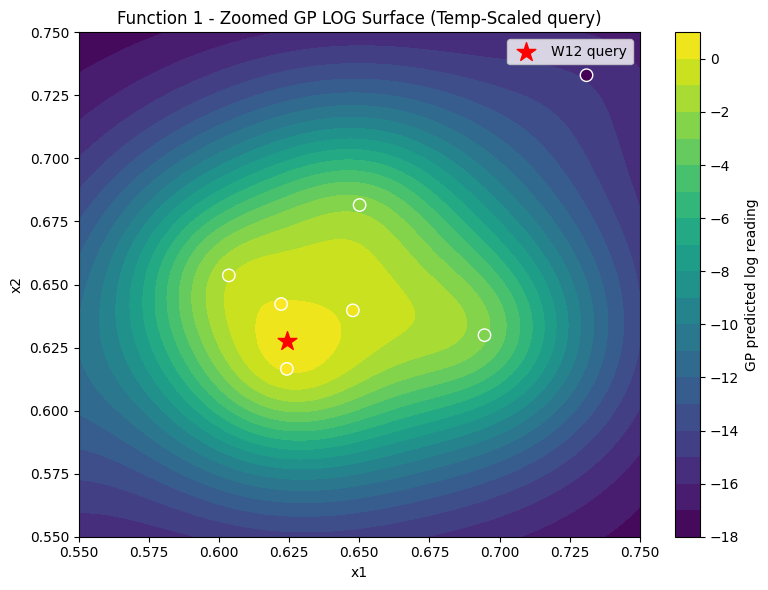

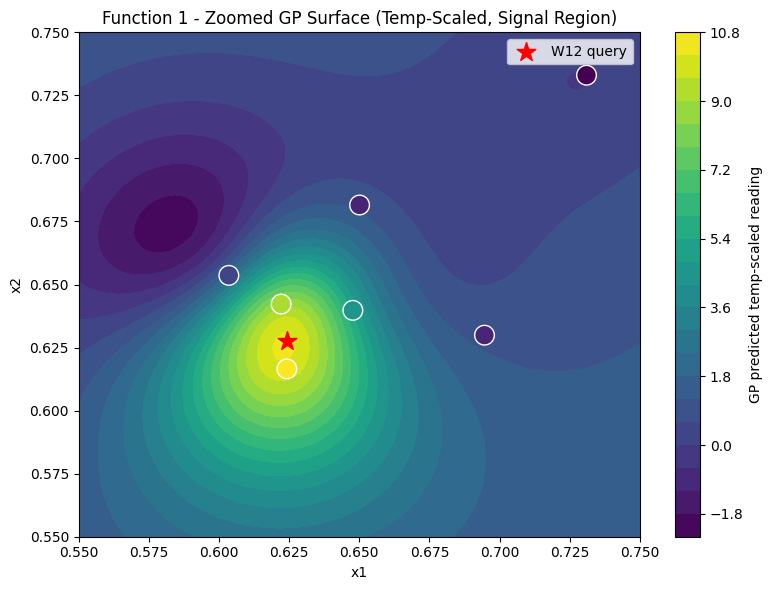

In [3]:
# =============================================================================
# FUNCTION 1 - Radiation Detection (2D)
# changes:
#    - replaced log10 transform with piecewise scaling to preserve magnitude
#      differences between top signal points (log10 compressed 1.347 and 1.144 to the same value)
#      this blinded the GP to the discrepancies between my best values
#    - added zoomed heatmap of signal region alongside full log10 landscape plot
#      (log10 GP retained for interpretability only, not used for acquisition)
#    - added week 11 to source 1 points for ls estimate 
# =============================================================================
 
print("=" * 60)
print("Function 1 - Week 12")
print("=" * 60)
 
inputs  = np.load('../Data/function_1/initial_inputs.npy')
outputs = np.load('../Data/function_1/initial_outputs.npy')
 
prev_queries = np.array([
    [0.959184, 0.836735],  
    [0.374540, 0.950714],  
    [0.694651, 0.629916],  
    [0.461537, 0.459084],  
    [0.618043, 0.460066], 
    [0.914142, 0.732619],
    [0.504751, 0.602966],
    [0.624182, 0.616547], # W8:  1.3466
    [0.603501, 0.653629], # W9:  0.0775
    [0.647707, 0.639762], # W10: 0.5893
    [0.622140, 0.642261], # W11: 1.1438
])
prev_outputs = np.array([
    -5.909566597235814e-107,
    -1.560646704467778e-117,
    -0.0016067678433140744,
    -0.000016877758079573665,
    2.602669489913104e-20,
    -2.694395789176799e-65,
    1.9491751435286236e-12,
    1.3466251251333927,
    0.07758657745022698,
    0.5893718994659691,
    1.1438544295250048,
])
 
all_inputs  = np.vstack([inputs, prev_queries])
all_outputs = np.hstack([outputs, prev_outputs])

# Piecewise scaling: preserves ordering across three distinct regimes
# dead zone (|y| < 1e-6) mapped to (0.0) (flat floor, no false gradient)
# weak signal (-0.004 to 0.07) mapped to [1, 2] (negatives + small positives)
# strong signal (>0.07) mapped to [2, 10] (stretched to give GP a better gradient)
def piecewise_scale(outputs):
    scaled = np.zeros(len(outputs))
    for i, y in enumerate(outputs):
        if np.abs(y) < 1e-6:  # dead zone 
            scaled[i] = 0.0
        elif y > 0.07:  # strong positive signal
            scaled[i] = np.interp(y, [0.07, 1.35], [2, 10])
        elif y > -0.004:  # weak signal 
            scaled[i] = np.interp(y, [-0.004, 0.07], [1, 2])
        else:  # remaining negatives classified as dead zone
            scaled[i] = 0.5
    return scaled

temp_readings = piecewise_scale(all_outputs)

print(f"\nAll points (sorted by piecewise-scaled value):")
sort_idx = np.argsort(temp_readings)[::-1]
for i in sort_idx:
    print(f"  {all_inputs[i]} --> output: {all_outputs[i]:.3e} --> scaled: {temp_readings[i]:.4f}")

print(f"\nScaled range: {temp_readings.min():.4f} to {temp_readings.max():.4f}")

# source-1 points used to to generate the ls estimate
source1_points = np.array([
    [0.624182, 0.616547],  # W8:  1.347 
    [0.603501, 0.653629],  # W9:  0.078
    [0.647707, 0.639762],  # W10: 0.5893 
    [0.622140, 0.642261],  # W11: 1.1438
])

pairs = [(0,1),(0,2),(1,2)]
dists = [np.linalg.norm(source1_points[i] - source1_points[j]) for i,j in pairs]
ls = np.mean(dists)
print(f"Length scale: {ls:.3f}")

# GP
kernel = Matern(nu=2.5, length_scale=ls, length_scale_bounds="fixed")
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=True)
gp.fit(all_inputs, temp_readings)

# EI over candidates
np.random.seed(42)
candidates = np.random.uniform(0, 1, (50000, 2))

mu, sigma = gp.predict(candidates, return_std=True)

# Expected Improvement
best_so_far = temp_readings.max() 
ei = compute_ei(mu, sigma, best_so_far, xi=0.1)

best_idx = np.argmax(ei)
query = candidates[best_idx]

print(f"\nWeek 12 Query: {format_query(query)}")
print(f"mu (log reading): {mu[best_idx]:.2f}, sigma: {sigma[best_idx]:.2f}, EI: {ei[best_idx]:.4f}")
 
# --- Log readings graph ---
# log10 graph for landscape visibility
# log-abs transform: measures detection strength on a log scale
# largest absolute value = strongest detection = highest log reading
# 1e-300 prevents log(0) for any exactly-zero readings
log_readings = np.log10(np.abs(all_outputs) + 1e-300)

# find the natural gap between signal and dead zone
# set floor at the midpoint of the largest gap in sorted log readings
sorted_logs = np.sort(log_readings)[::-1]
gaps = sorted_logs[:-1] - sorted_logs[1:]
largest_gap_idx = np.argmax(gaps)
floor = (sorted_logs[largest_gap_idx] + sorted_logs[largest_gap_idx + 1]) / 2

print(f"Largest gap: {sorted_logs[largest_gap_idx]:.1f} to {sorted_logs[largest_gap_idx + 1]:.1f}")
print(f"Floor set at: {floor:.1f}")

# clip: all dead-zone points get the same floor value
ceiling = np.max(np.log10(np.abs(all_outputs) + 1e-300))
log_readings = np.clip(log_readings, floor, ceiling)
 
# identify the strongest detection
best_detection_idx = np.argmax(log_readings)
print(f"Strongest detection: {all_outputs[best_detection_idx]:.6e} at {all_inputs[best_detection_idx]}")
print(f"  log reading: {log_readings[best_detection_idx]:.1f}")
print(f"Log reading range: {log_readings.min():.1f} to {log_readings.max():.1f}")
 
# print all points for verification
print(f"\nAll points (sorted by detection strength):")
sort_idx = np.argsort(log_readings)[::-1]
for i in sort_idx:
    print(f"  {all_inputs[i]} --> output: {all_outputs[i]:.3e} --> log reading: {log_readings[i]:.1f}")

# GP log readings
kernel = Matern(nu=2.5, length_scale=ls, length_scale_bounds="fixed")
gp_log = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=True)
gp_log.fit(all_inputs, log_readings) # LOG READINGS VERSION

# --- Interpretability: 2D heatmap of GP predicted surface ---
grid_n = 100
x1_grid = np.linspace(0, 1, grid_n)
x2_grid = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1.ravel(), X2.ravel()])
 
mu_grid_log, _ = gp_log.predict(grid_points, return_std=True)
mu_grid_log = mu_grid_log.reshape(grid_n, grid_n)

plt.figure(figsize=(8, 6))

plt.contourf(X1, X2, mu_grid_log, levels=20, cmap='viridis')
plt.colorbar(label='GP predicted log reading (higher = stronger detection)')
plt.scatter(all_inputs[:, 0], all_inputs[:, 1], c=log_readings,
            edgecolors='white', s=80, cmap='viridis', zorder=5,
            vmin=floor, vmax=ceiling)
 
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Function 1 - GP LOG Surface (Rank-Transformed Outputs)')
plt.tight_layout()
plt.show()

# --- zoomed in temp_readings query on log10 landscape  
plt.figure(figsize=(8, 6))
x1_zoom = np.linspace(0.55, 0.75, 100)
x2_zoom = np.linspace(0.55, 0.75, 100)
X1z, X2z = np.meshgrid(x1_zoom, x2_zoom)
grid_zoom = np.column_stack([X1z.ravel(), X2z.ravel()])
mu_zoom_log, _ = gp_log.predict(grid_zoom, return_std=True)
mu_zoom_log = mu_zoom_log.reshape(100, 100)
plt.contourf(X1z, X2z, mu_zoom_log, levels=20, cmap='viridis')
plt.colorbar(label='GP predicted log reading')
mask = ((all_inputs[:, 0] > 0.55) & (all_inputs[:, 0] < 0.75) &
        (all_inputs[:, 1] > 0.55) & (all_inputs[:, 1] < 0.75))
plt.scatter(all_inputs[mask, 0], all_inputs[mask, 1], c=log_readings[mask],
            edgecolors='white', s=80, cmap='viridis', zorder=5)
plt.scatter(query[0], query[1], marker='*', c='red', s=200, zorder=10, label='W12 query')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Function 1 - Zoomed GP LOG Surface (Temp-Scaled query)')
plt.legend()
plt.tight_layout()
plt.show()

# zoomed-in temp readings graph
pad = 0.05
x1_zoom = np.linspace(0.55, 0.75, 100)
x2_zoom = np.linspace(0.55, 0.75, 100)
X1z, X2z = np.meshgrid(x1_zoom, x2_zoom)
grid_zoom = np.column_stack([X1z.ravel(), X2z.ravel()])

mu_zoom, _ = gp.predict(grid_zoom, return_std=True)
mu_zoom = mu_zoom.reshape(100, 100)

plt.figure(figsize=(8, 6))
plt.contourf(X1z, X2z, mu_zoom, levels=20, cmap='viridis')
plt.colorbar(label='GP predicted temp-scaled reading')
plt.scatter(all_inputs[mask, 0], all_inputs[mask, 1], c=temp_readings[mask],
            edgecolors='white', s=200, cmap='viridis', 
            vmin=temp_readings.min(), vmax=temp_readings.max(), zorder=5)
plt.scatter(query[0], query[1], marker='*', c='red', s=200, zorder=10, label='W12 query')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Function 1 - Zoomed GP Surface (Temp-Scaled, Signal Region)')
plt.legend()
plt.tight_layout()
plt.show()


# Function 2 - week 12


Function 2 - Week 12
Total points: 21
Current best: 0.685

Feature importances: x1=0.960, x2=0.040

Week 12 Query: 0.691307-0.352737
  GP mean: 0.6553
  GP std:  0.1421
  UCB score: 0.7263  (kappa=0.5)
5-fold NLPD: -0.262
LOO at W8: predicted 0.4813 ± 0.0871, actual 0.6848
LOO residual std: 0.1772


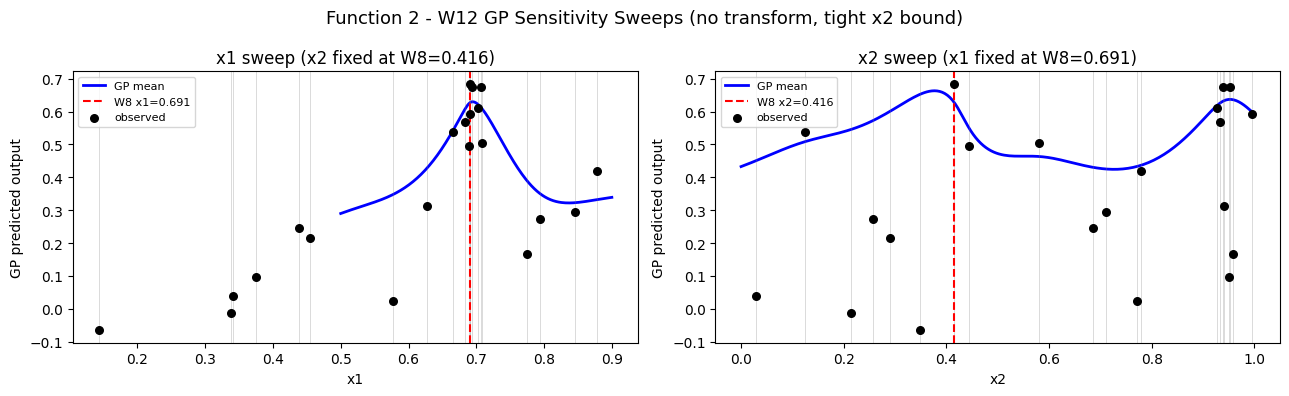

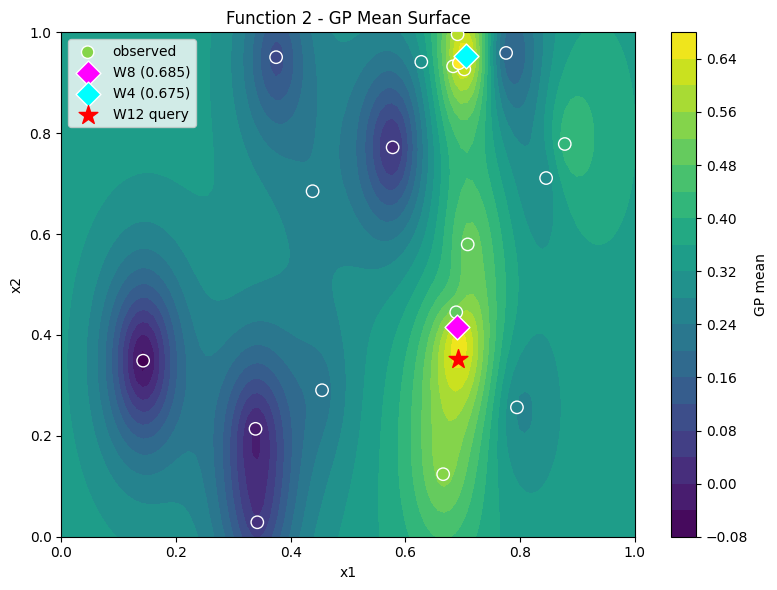

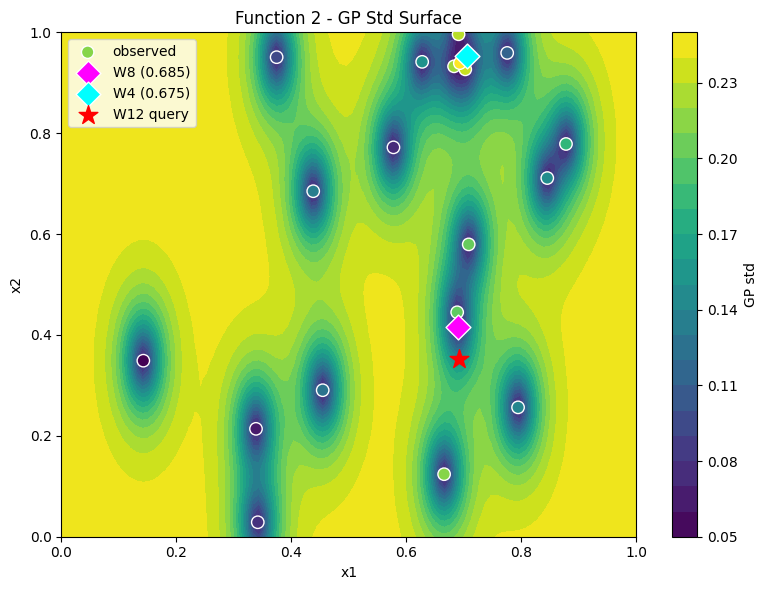

In [4]:
# =============================================================================
# FUNCTION 2 - Noisy Log-Likelihood (2D)
# changes:
#   - Dropped Yeo-Johnson: W11 result (predicted 0.667, observed 0.494) confirmed the transform was overfitting
#   - lowered Matern nu from 2.5 to 1.5 (rougher kernel, better for noisy data)
#   - WhiteKernel lower bounds raised to (0.005, 0.2): LOO residuals show noise roughly at ~0.18, previous bounds let GP assume ~0.01
#   - Added fixed heteroscedastic with per-point alpha at W8/W11:
#       (sigma^2 = 0.018 from |W8 - W11| / sqrt(2)): 
#        to try and encode our estimate known model overprediction as noise
#   - Length-scale bounds retained: x1 (0.01, 1.0), x2 (0.01, 0.15)
#       Tested 15 configs via 5-fold NLPD: looser x2 gives better NLPD
#       (-0.628 at x2 ls=10) but treats x2 as noise, contradicting observed potential inetraction (different y at same x1, different x2)
#       Tight x2 retained: stationary ARD can't capture x2 non-stationarity tight bound preserves observed structure for acquisition
#   - raised n_restarts_optimizer from 20 to 100
# =============================================================================

print("\n" + "=" * 60)
print("Function 2 - Week 12")
print("=" * 60)

initial_inputs  = np.load('../Data/function_2/initial_inputs.npy')
initial_outputs = np.load('../Data/function_2/initial_outputs.npy')

prev_queries = np.array([
    [0.775510, 0.959184],  # W1:  0.166
    [0.683114, 0.932567],  # W2:  0.570
    [0.794441, 0.256481],  # W3:  0.273
    [0.706387, 0.952221],  # W4:  0.675
    [0.693183, 0.938929],  # W5:  0.674
    [0.374540, 0.950714],  # W6:  0.096
    [0.627660, 0.941490],  # W7:  0.311
    [0.690609, 0.415564],  # W8:  0.684 (best)
    [0.708605, 0.579596],  # W9:  0.503
    [0.690966, 0.996157],  # W10: 0.593
    [0.688548, 0.445022],  # W11: 0.494
])
prev_outputs = np.array([
    0.16576674,
    0.56974583,
    0.27313450,
    0.67545988,
    0.67430262,
    0.09612224849190841,
    0.3113471043593484,
    0.6848335582399823,
    0.5035276611583426,
    0.5934512672260965,
    0.4940992655581413,
])

all_inputs  = np.vstack([initial_inputs, prev_queries])
all_outputs = np.hstack([initial_outputs, prev_outputs])

print(f"Total points: {len(all_outputs)}")
print(f"Current best: {all_outputs.max():.3f}")

# --- RF for feature importances only ---
rf = RandomForestRegressor(n_estimators=500, max_depth=3, min_samples_leaf=2, random_state=42)
rf.fit(all_inputs, all_outputs)
print(f"\nFeature importances: x1={rf.feature_importances_[0]:.3f}, x2={rf.feature_importances_[1]:.3f}")

# --- GP with ARD bounds ---
kernel = (Matern(length_scale=[0.1, 0.05],
                 length_scale_bounds=[(0.05, 1.0), (0.02, 0.15)],
                 nu=1.5)
          + WhiteKernel(noise_level=0.04,
                        noise_level_bounds=(0.005, 0.2)))

# trying heteroscedastic noise
w8_idx = np.where((all_inputs == [0.690609, 0.415564]).all(axis=1))[0][0]
w11_idx = np.where((all_inputs == [0.688548, 0.445022]).all(axis=1))[0][0]

# adding alpha at week 8 and 11 to give a better estimate
alpha_per_point = np.full(len(all_outputs), 1e-10)
alpha_per_point[w8_idx] = 0.018  
alpha_per_point[w11_idx] = 0.018

gp = GaussianProcessRegressor(kernel=kernel, alpha=alpha_per_point,
                              n_restarts_optimizer=100, normalize_y=True)
gp.fit(all_inputs, all_outputs)

np.random.seed(42)
candidates = np.random.uniform(0, 1, (50000, 2))
gp_mean, gp_std = gp.predict(candidates, return_std=True)
kappa = 1.5
ucb_scores = gp_mean + kappa * gp_std
query = candidates[np.argmax(ucb_scores)]

# --- Uniform candidates ---
np.random.seed(42)
n_candidates = 50000
candidates = np.random.uniform(0, 1, (n_candidates, 2))

# --- UCB acquisition in transformed space ---
gp_mean, gp_std = gp.predict(candidates, return_std=True)

kappa      = 0.5
ucb_scores = gp_mean + kappa * gp_std

best_idx        = np.argmax(ucb_scores)
query           = candidates[best_idx]
query_mean = gp_mean[best_idx]

print(f"\nWeek 12 Query: {format_query(query)}")
print(f"  GP mean: {query_mean:.4f}")
print(f"  GP std:  {gp_std[best_idx]:.4f}")
print(f"  UCB score: {ucb_scores[best_idx]:.4f}  (kappa={kappa})")

# --- Interpretability
# LOO Kfold NLPD
nlpds = []
for train_idx, test_idx in KFold(n_splits=5, shuffle=True, random_state=42).split(all_inputs):
    g = clone(gp)
    g.alpha = alpha_per_point[train_idx]
    g.fit(all_inputs[train_idx], all_outputs[train_idx])
    mu, sd = g.predict(all_inputs[test_idx], return_std=True)
    nlpds.append(-norm.logpdf(all_outputs[test_idx], mu, sd).mean())
print(f"5-fold NLPD: {np.mean(nlpds):.3f}")

# W8 LOO
w8_idx_loo = np.argmax(all_outputs)
mask = np.ones(len(all_outputs), dtype=bool)
mask[w8_idx_loo] = False
gp_loo = clone(gp)
gp_loo.alpha = alpha_per_point[mask]
gp_loo.fit(all_inputs[mask], all_outputs[mask])
w8_pred, w8_std = gp_loo.predict(all_inputs[w8_idx_loo:w8_idx_loo+1], return_std=True)
print(f"LOO at W8: predicted {w8_pred[0]:.4f} ± {w8_std[0]:.4f}, actual {all_outputs[w8_idx_loo]:.4f}")

# --- test residuals
residuals = []
for train_idx, test_idx in LeaveOneOut().split(all_inputs):
    g = clone(gp)
    g.alpha = alpha_per_point[train_idx]
    g.fit(all_inputs[train_idx], all_outputs[train_idx])
    pred = g.predict(all_inputs[test_idx])
    residuals.append(all_outputs[test_idx][0] - pred[0])
residuals = np.array(residuals)
print(f"LOO residual std: {residuals.std():.4f}")

# --- Sensitivity sweeps ---
w8_1d    = np.array([0.690609, 0.415564])
x1_sweep = np.linspace(0.50, 0.90, 200)
x1_test  = np.column_stack([x1_sweep, np.full(200, w8_1d[1])])
x1_mu    = gp.predict(x1_test)

x2_sweep = np.linspace(0.0, 1.0, 200)
x2_test  = np.column_stack([np.full(200, w8_1d[0]), x2_sweep])
x2_mu    = gp.predict(x2_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(x1_sweep, x1_mu, 'b-', lw=2, label='GP mean')
for pt_obs in all_inputs:
    ax.axvline(pt_obs[0], color='grey', lw=0.5, alpha=0.4)
ax.axvline(w8_1d[0], color='red', lw=1.5, linestyle='--', label=f'W8 x1={w8_1d[0]:.3f}')
ax.scatter(all_inputs[:, 0], all_outputs, c='black', s=30, zorder=5, label='observed')
ax.set_xlabel('x1')
ax.set_ylabel('GP predicted output')
ax.set_title('x1 sweep (x2 fixed at W8=0.416)')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(x2_sweep, x2_mu, 'b-', lw=2, label='GP mean')
for pt_obs in all_inputs:
    ax.axvline(pt_obs[1], color='grey', lw=0.5, alpha=0.4)
ax.axvline(w8_1d[1], color='red', lw=1.5, linestyle='--', label=f'W8 x2={w8_1d[1]:.3f}')
ax.scatter(all_inputs[:, 1], all_outputs, c='black', s=30, zorder=5, label='observed')
ax.set_xlabel('x2')
ax.set_ylabel('GP predicted output')
ax.set_title('x2 sweep (x1 fixed at W8=0.691)')
ax.legend(fontsize=8)

plt.suptitle('Function 2 - W12 GP Sensitivity Sweeps (no transform, tight x2 bound)', fontsize=13)
plt.tight_layout()
plt.show()

# --- GP plots 
# Identify top 2 by output value (W4 and W8 by exact coordinates)
w4_coords = [0.706387, 0.952221]
w8_coords = [0.690609, 0.415564]
w4_idx = np.where((all_inputs == w4_coords).all(axis=1))[0][0]
w8_idx = np.where((all_inputs == w8_coords).all(axis=1))[0][0]

mask_top2 = np.zeros(len(all_outputs), dtype=bool)
mask_top2[[w4_idx, w8_idx]] = True

grid_n = 100
x1_grid = np.linspace(0, 1, grid_n)
x2_grid = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1.ravel(), X2.ravel()])

mu_grid, sd_grid = gp.predict(grid_points, return_std=True)
mu_grid = mu_grid.reshape(grid_n, grid_n)
sd_grid = sd_grid.reshape(grid_n, grid_n)

# GP mean
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, mu_grid, levels=20, cmap='viridis')
plt.colorbar(label='GP mean')
plt.scatter(all_inputs[~mask_top2, 0], all_inputs[~mask_top2, 1],
            c=all_outputs[~mask_top2], edgecolors='white', s=80,
            cmap='viridis', zorder=5, label='observed')
plt.scatter(*all_inputs[w8_idx], c='magenta', edgecolors='white',
            s=160, marker='D', zorder=6, label=f'W8 ({all_outputs[w8_idx]:.3f})')
plt.scatter(*all_inputs[w4_idx], c='cyan', edgecolors='white',
            s=160, marker='D', zorder=6, label=f'W4 ({all_outputs[w4_idx]:.3f})')
plt.scatter(query[0], query[1], marker='*', c='red', s=200,
            zorder=10, label='W12 query')
plt.xlabel('x1'); plt.ylabel('x2')
plt.title('Function 2 - GP Mean Surface')
plt.legend()
plt.tight_layout()
plt.show()

# GP std
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, sd_grid, levels=20, cmap='viridis')
plt.colorbar(label='GP std')
plt.scatter(all_inputs[~mask_top2, 0], all_inputs[~mask_top2, 1],
            c=all_outputs[~mask_top2], edgecolors='white', s=80,
            cmap='viridis', zorder=5, label='observed')
plt.scatter(*all_inputs[w8_idx], c='magenta', edgecolors='white',
            s=160, marker='D', zorder=6, label=f'W8 ({all_outputs[w8_idx]:.3f})')
plt.scatter(*all_inputs[w4_idx], c='cyan', edgecolors='white',
            s=160, marker='D', zorder=6, label=f'W4 ({all_outputs[w4_idx]:.3f})')
plt.scatter(query[0], query[1], marker='*', c='red', s=200,
            zorder=10, label='W12 query')
plt.xlabel('x1'); plt.ylabel('x2')
plt.title('Function 2 - GP Std Surface')
plt.legend()
plt.tight_layout()
plt.show()

# Function 3 - week 12


Function 3 - Week 12
Total points: 26, best: -0.0000607

Top 10 GB candidates:
  1: 0.441377-0.540342-0.464779, GB predicted: -0.000023
  2: 0.443299-0.540229-0.465393, GB predicted: -0.000023
  3: 0.443507-0.540219-0.464968, GB predicted: -0.000023
  4: 0.442596-0.539737-0.465655, GB predicted: -0.000023
  5: 0.443658-0.540147-0.464317, GB predicted: -0.000023
  6: 0.442383-0.539822-0.465385, GB predicted: -0.000023
  7: 0.444816-0.540294-0.464365, GB predicted: -0.000023
  8: 0.443826-0.539707-0.464859, GB predicted: -0.000023
  9: 0.441160-0.539650-0.464644, GB predicted: -0.000023
  10: 0.444186-0.539876-0.464456, GB predicted: -0.000023

Week 12 Query: 0.441355-0.539989-0.464826
GB predicted: -0.000023


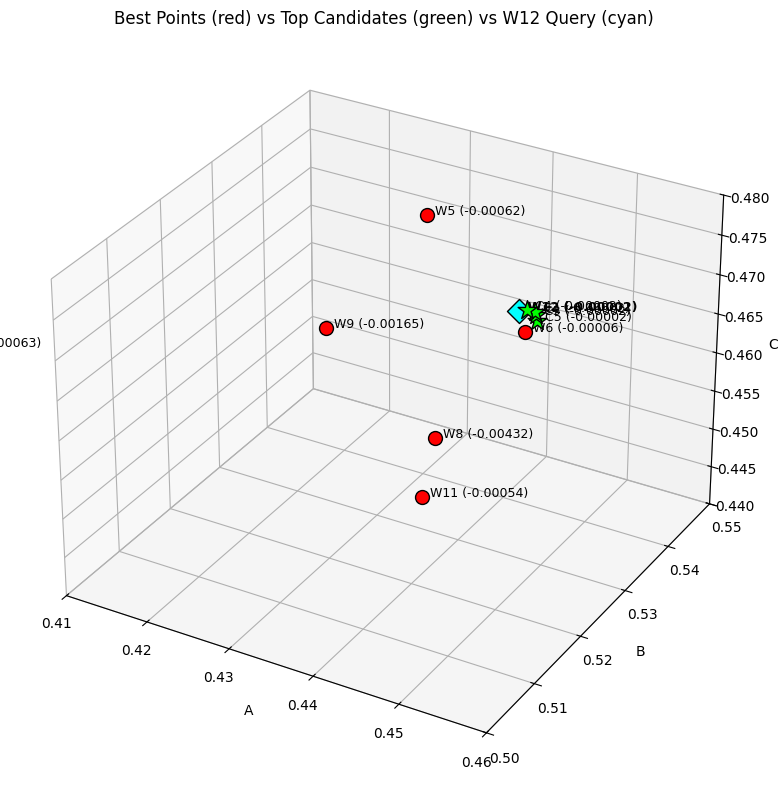

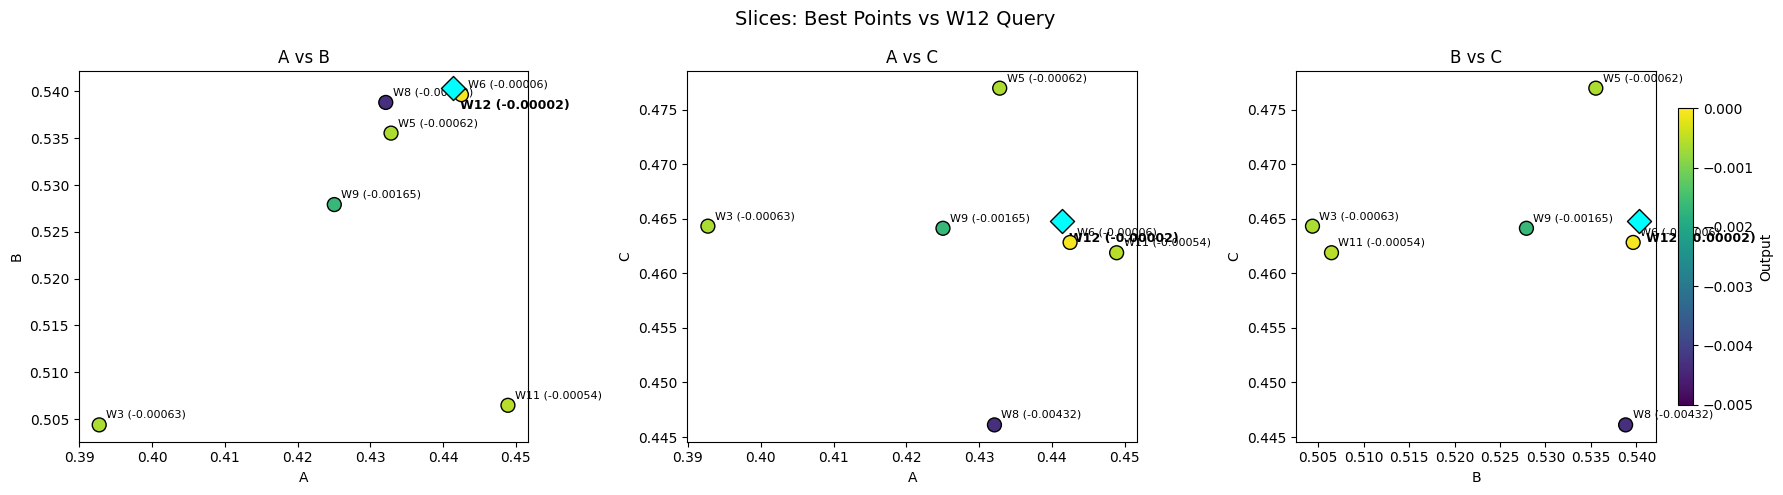

In [5]:
# =============================================================================
# FUNCTION 3 - Drug Discovery (3D)
# changes:
#     - Switched surrogate: from ExtraTrees to Gradient Boosting (GB) 
#        (ExtraTrees underpredicted best points from weeks 7-10)
#     - GB Using huber loss to be more robust to the wide range of output magnitudes
#         other loss functions caused the 
#     - Sample candidates locally around best observed point (W6) at two scales:
#         tight (std=0.003) for fine-grained search, wide (std=0.008) for slight exploration
#     - added interpretability plots, to visualise top 10 candiates relative to best points
# 
# Note on GP's flat predictions for candidates:
#     All top candidates tie at the same predicted value because GB is piecewise constant
#     candidates are likely within the same leaf get identical predictions.
#     GB's inability to rank fine-grained points near the optimum is an accepted limitation at this stage
#     redictions stay within the range of observed values - attempted alternatives did not: 
#     tried: Squared-error GB, Ridge Regression, and Local quadratic fits had R2 ~0.15)
# =============================================================================

print("\n" + "=" * 60)
print("Function 3 - Week 12")
print("=" * 60)

f3_inputs  = np.load('../Data/function_3/initial_inputs.npy')
f3_outputs = np.load('../Data/function_3/initial_outputs.npy')

prev_queries = np.array([
    [0.378956, 0.302768, 0.459346],  # W1:  -0.0291
    [0.315339, 0.088659, 0.415174],  # W2:  -0.0623
    [0.392735, 0.504381, 0.464332],  # W3:  -0.00063
    [0.498607, 0.467046, 0.477827],  # W4:  -0.00294
    [0.432840, 0.535542, 0.476983],  # W5:  -0.000617
    [0.442511, 0.539648, 0.462840],  # W6:  -0.0000607 (best)
    [0.427601, 0.442546, 0.649322],  # W7:  -0.0906
    [0.432117, 0.538819, 0.446114],  # W8:  -0.0043
    [0.425043, 0.527911, 0.464138],  # W9:  -0.0016
    [0.439519, 0.538278, 0.481340],  # W10: -0.0276
    [0.448908, 0.506472, 0.461896],  # W11: -0.0005389 (2nd best)
])
prev_outputs = np.array([
    -0.02906213067759293,
    -0.06230989251412482,
    -0.0006328364393800658,
    -0.0029446702316140265,
    -0.0006169444563794807,
    -0.00006071018004296725,
    -0.09063996317418548,
    -0.004316355713810623,
    -0.001648812524906173,
    -0.027616584476348058,
    -0.000538948359981463,
])

X = np.vstack([f3_inputs, prev_queries])
Y = np.hstack([f3_outputs, prev_outputs])

print(f"Total points: {len(Y)}, best: {Y.max():.7f}")

# --- Polynomial features ---
poly   = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = ['A', 'B', 'C', 'A*B', 'A*C', 'B*C', 'A^2', 'B^2', 'C^2']

# --- Gradient Boosting Model (replaces Extra Trees on Poly Features for candidate selection)
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    loss='huber',
    random_state=42
)

gb.fit(X_poly, Y)

# --- Local candidate search 
np.random.seed(42)

# Best observed point so far
best_point = X[np.argmax(Y)]

# Two-scale local sampling (helps avoid missing sharp optimum)
candidates_tight = best_point + np.random.normal(0, 0.003, (1500, 3))
candidates_wide  = best_point + np.random.normal(0, 0.008, (1500, 3))

candidates = np.vstack([candidates_tight, candidates_wide])
candidates = np.clip(candidates, 0, 1)

cand_poly = poly.transform(candidates)


# --- Prediction + selection 
gb_preds = gb.predict(cand_poly)
best_idx = np.argmax(gb_preds)
query    = candidates[best_idx]


# --- Top candidates ---
top_n = 10
top_indices = np.argsort(gb_preds)[::-1][:top_n]

print(f"\nTop {top_n} GB candidates:")
for i, idx in enumerate(top_indices):
    print(f"  {i+1}: {format_query(candidates[idx])}, GB predicted: {gb_preds[idx]:.6f}")

print(f"\nWeek 12 Query: {format_query(query)}")
print(f"GB predicted: {gb_preds[best_idx]:.6f}")


# --- Interpretability Plots ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

best_weeks = [
    ('W6',  [0.442511, 0.539648, 0.462840], -0.0000607),
    ('W11', [0.448908, 0.506472, 0.461896], -0.000539),
    ('W5',  [0.432840, 0.535542, 0.476983], -0.000617),
    ('W3',  [0.392735, 0.504381, 0.464332], -0.000633),
    ('W9',  [0.425043, 0.527911, 0.464138], -0.001649),
    ('W8',  [0.432117, 0.538819, 0.446114], -0.004316),
]
for label, coords, val in best_weeks:
    ax.scatter(*coords, c='red', s=100, edgecolors='black', zorder=5)
    ax.text(coords[0], coords[1], coords[2], f'  {label} ({val:.5f})', fontsize=9)

# This week's query (C1) - different marker
c1 = candidates[np.argsort(gb_preds)[::-1][0]]
p1 = gb_preds[np.argsort(gb_preds)[::-1][0]]
ax.scatter(*c1, c='cyan', marker='D', s=150, edgecolors='black', zorder=7)
ax.text(c1[0], c1[1], c1[2], f'  W12 ({p1:.5f})', fontsize=9, fontweight='bold')

# Other top candidates
top5_idx = np.argsort(gb_preds)[::-1][1:5]
top5_cands = candidates[top5_idx]
top5_preds = gb_preds[top5_idx]
for i, (c, p) in enumerate(zip(top5_cands, top5_preds)):
    ax.scatter(*c, c='lime', marker='*', s=200, edgecolors='black', zorder=6)
    ax.text(c[0], c[1], c[2], f'  C{i+2} ({p:.5f})', fontsize=9)

ax.set_xlim(0.41, 0.46)
ax.set_ylim(0.50, 0.55)
ax.set_zlim(0.44, 0.48)
ax.set_xlabel('A')
ax.set_ylabel('B')
ax.set_zlabel('C')
ax.set_title('Best Points (red) vs Top Candidates (green) vs W12 Query (cyan)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

best_weeks = [
    ('W3',  [0.392735, 0.504381, 0.464332], -0.000633),
    ('W5',  [0.432840, 0.535542, 0.476983], -0.000617),
    ('W6',  [0.442511, 0.539648, 0.462840], -0.0000607),
    ('W8',  [0.432117, 0.538819, 0.446114], -0.004316),
    ('W9',  [0.425043, 0.527911, 0.464138], -0.001649),
    ('W11', [0.448908, 0.506472, 0.461896], -0.000539),
]
bw_coords = np.array([b[1] for b in best_weeks])
bw_vals = np.array([b[2] for b in best_weeks])
bw_labels = [b[0] for b in best_weeks]

w12 = candidates[np.argsort(gb_preds)[::-1][0]]
w12_pred = gb_preds[np.argsort(gb_preds)[::-1][0]]

dims = ['A', 'B', 'C']
pairs = [(0, 1, 'A', 'B'), (0, 2, 'A', 'C'), (1, 2, 'B', 'C')]

for ax, (d1, d2, n1, n2) in zip(axes, pairs):
    sc = ax.scatter(bw_coords[:, d1], bw_coords[:, d2], c=bw_vals, cmap='viridis',
                    s=100, edgecolors='black', zorder=5, vmin=-0.005, vmax=0)
    for i, label in enumerate(bw_labels):
        ax.annotate(f'{label} ({bw_vals[i]:.5f})', (bw_coords[i, d1], bw_coords[i, d2]),
                    fontsize=8, xytext=(5, 5), textcoords='offset points')
    ax.scatter(w12[d1], w12[d2], c='cyan', marker='D', s=150, edgecolors='black', zorder=7)
    ax.annotate(f'W12 ({w12_pred:.5f})', (w12[d1], w12[d2]),
                fontsize=9, fontweight='bold', xytext=(5, -15), textcoords='offset points')
    ax.set_xlabel(n1)
    ax.set_ylabel(n2)
    ax.set_title(f'{n1} vs {n2}')

plt.colorbar(sc, ax=axes[-1], label='Output', shrink=0.8)
plt.suptitle('Slices: Best Points vs W12 Query', fontsize=14)
plt.tight_layout()
plt.show()

# Function 4 - week 12


Function 4 - Week 12
Total points: 41, best: 0.6309

Candidates: 5000 W2 + 3000 W10 + 2000 global = 10000 total
Fitted kernel: 0.714**2 * Matern(length_scale=0.3, nu=2.5)
Log-marginal-likelihood: -22.6639

Week 12 Query: 0.396225-0.408429-0.392689-0.401539
mean: 0.423
std:  0.268
UCB:  0.557157
Pure mean:  0.396225-0.408429-0.392689-0.401539  mean=0.423  std=0.268
UCB k=0.5:  0.396225-0.408429-0.392689-0.401539  mean=0.423  std=0.268
Same point: True

Model's prediction of week 2

W2 point:  mean=0.350  std=0.203
W12 query: mean=0.423  std=0.268


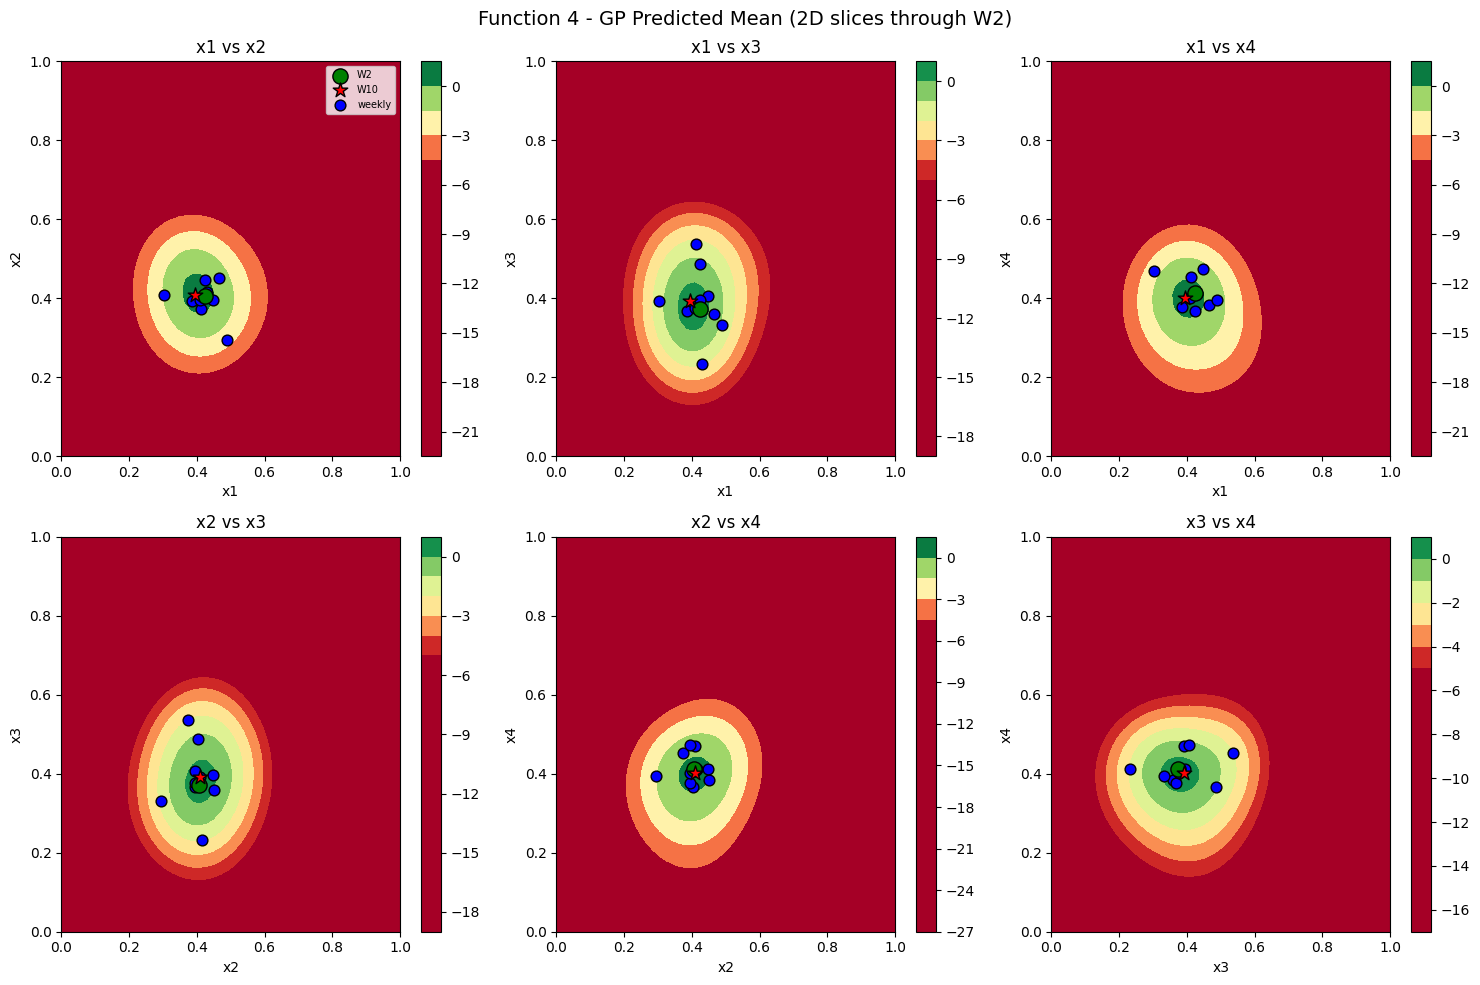

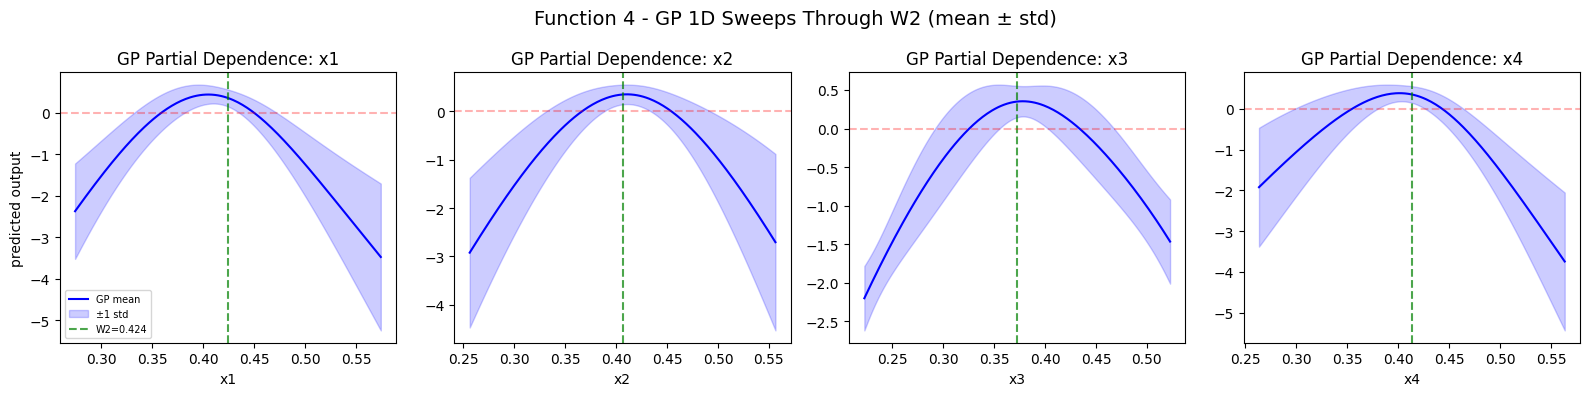

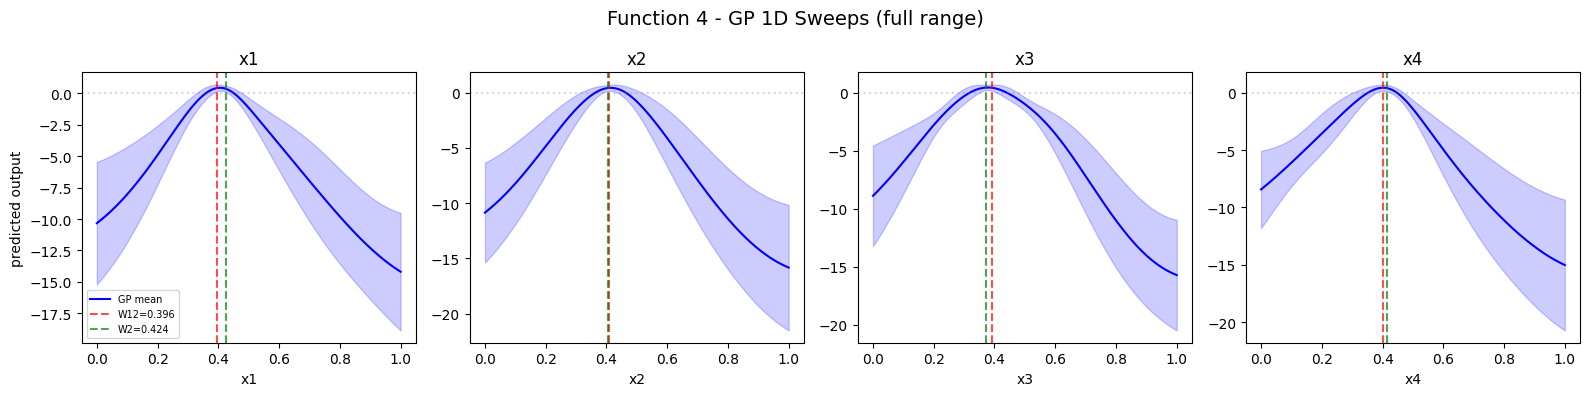

Method               Query                                         mean     std     
-------------------------------------------------------------------------------------
EI xi=0.0            0.369804-0.446641-0.364982-0.379039           -0.075   0.523   
EI xi=0.01           0.369804-0.446641-0.364982-0.379039           -0.075   0.523   
EI xi=0.05           0.372479-0.474117-0.374242-0.371613           -0.458   0.719   
EI xi=0.1            0.466059-0.308749-0.211335-0.186727           -5.944   3.060   
UCB kappa=0.5        0.397470-0.418581-0.389259-0.390540           0.351    0.221   
UCB kappa=1.0        0.397470-0.418581-0.389259-0.390540           0.351    0.221   
UCB kappa=1.5        0.384840-0.439186-0.376733-0.390654           0.190    0.357   
UCB kappa=2.0        0.372479-0.474117-0.374242-0.371613           -0.458   0.719   


In [6]:
# =============================================================================
# FUNCTION 4 - Warehouse Placement (4D)
# changes:
#   - lowered kernel length scale from 0.4 to 0.30 based on top10 LOO diagnostics calibration improved from 40% to 70% 
#   - at ls=0.3 UCB kappa=0.5 selects the same point as pure mean
#       GP's confidence and UCB prediction are aligned in the query region
# =============================================================================
 
print("\n" + "=" * 60)
print("Function 4 - Week 12")
print("=" * 60)
 
f4_inputs  = np.load('../Data/function_4/initial_inputs.npy')
f4_outputs = np.load('../Data/function_4/initial_outputs.npy')
 
prev_queries = np.array([
    [0.466173, 0.451984, 0.359193, 0.383111],  # W1:  -0.965
    [0.424201, 0.406375, 0.372722, 0.413313],  # W2:  +0.631 (best)
    [0.413541, 0.373697, 0.536536, 0.453354],  # W3:  -2.150
    [0.424125, 0.404716, 0.487507, 0.367688],  # W4:  -0.992
    [0.488793, 0.294975, 0.332280, 0.395576],  # W5:  -2.463
    [0.303872, 0.408521, 0.392275, 0.469543],  # W6:  -2.141
    [0.447976, 0.395249, 0.406174, 0.473345],  # W7:  -1.249
    [0.431511, 0.415976, 0.232614, 0.411417],  # W8:  -1.993
    [0.425192, 0.446783, 0.395943, 0.413089],  # W9:  +0.1866
    [0.386937, 0.394308, 0.366806, 0.377180],  # W10: +0.1978
    [0.409378, 0.395989, 0.376227, 0.401553],  # W11: +0.3179 (2nd best)
])
prev_outputs = np.array([
    -0.9654345395220925, 
    0.6308582112564989, 
    -2.1500998298742817,
    -0.9915950770116662, 
    -2.4630197287139697, 
    -2.1414388028868454,
    -1.2497635252595596,
    -1.9932051275194236,
    0.1866021739608965,
    0.19781147766983453,
    0.3179112169112597,
])
 
f4_all_inputs  = np.vstack([f4_inputs, prev_queries])
f4_all_outputs = np.hstack([f4_outputs, prev_outputs])
print(f"Total points: {len(f4_all_outputs)}, best: {f4_all_outputs.max():.4f}")

# --- Candidate generation ---
np.random.seed(42)

week2_query = np.array([0.424201, 0.406375, 0.372722, 0.413313])
week11_query = np.array([0.409378, 0.395989, 0.376227, 0.401553])

candidates_w2 = np.array([np.clip(week2_query + np.random.normal(0, 0.08, 4), 0, 1) for _ in range(5000)])
candidates_w11 = np.array([np.clip(week11_query + np.random.normal(0, 0.08, 4), 0, 1) for _ in range(3000)])
candidates_global = np.random.uniform(0, 1, size=(2000, 4))

candidates = np.vstack([candidates_w2, candidates_w11, candidates_global])
print(f"\nCandidates: {len(candidates_w2)} W2 + {len(candidates_w11)} W10 + {len(candidates_global)} global = {len(candidates)} total")

# --- GP surrogate ---
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
    length_scale=0.3,
    length_scale_bounds='fixed',
    nu=2.5,
)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, alpha=1e-3, normalize_y=True)
gp.fit(f4_all_inputs, f4_all_outputs)

print(f"Fitted kernel: {gp.kernel_}")
print(f"Log-marginal-likelihood: {gp.log_marginal_likelihood_value_:.4f}")

# --- UCB acquisition ---
mu, sigma = gp.predict(candidates, return_std=True)
kappa = 0.5
ucb = mu + kappa * sigma

best_index = np.argmax(ucb)
query = candidates[best_index]

print(f"\nWeek 12 Query: {format_query(query)}")
print(f"mean: {mu[best_index]:.3f}")
print(f"std:  {sigma[best_index]:.3f}")
print(f"UCB:  {ucb[best_index]:.6f}")

mean_idx = np.argmax(mu)
ucb_idx = np.argmax(mu + 0.5 * sigma)
print(f"Pure mean:  {format_query(candidates[mean_idx])}  mean={mu[mean_idx]:.3f}  std={sigma[mean_idx]:.3f}")
print(f"UCB k=0.5:  {format_query(candidates[ucb_idx])}  mean={mu[ucb_idx]:.3f}  std={sigma[ucb_idx]:.3f}")
print(f"Same point: {mean_idx == ucb_idx}")


# --- Diagnostics
# how it predicts week 2
w2_mu, w2_std = gp.predict(week2_query.reshape(1, -1), return_std=True)
print("\nModel's prediction of week 2")
print(f"\nW2 point:  mean={w2_mu[0]:.3f}  std={w2_std[0]:.3f}")
print(f"W12 query: mean={mu[best_index]:.3f}  std={sigma[best_index]:.3f}")

# --- Interpretability plots
# 2D GP predicted mean -- sweep pairs of dimensions through W2
dim_names = ['x1', 'x2', 'x3', 'x4']
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (d1, d2) in enumerate(pairs):
    ax = axes[idx]
    res = 50
    v1 = np.linspace(0, 1, res)
    v2 = np.linspace(0, 1, res)
    grid = np.tile(week2_query, (res * res, 1))
    g1, g2 = np.meshgrid(v1, v2)
    grid[:, d1] = g1.ravel()
    grid[:, d2] = g2.ravel()

    pred = gp.predict(grid).reshape(res, res)
    contour = ax.contourf(v1, v2, pred, levels=20, cmap='RdYlGn', vmin=-5, vmax=1)
    plt.colorbar(contour, ax=ax)

    ax.scatter(week2_query[d1], week2_query[d2], c='green', edgecolors='black', s=120, zorder=5, label='W2')
    ax.scatter(query[d1], query[d2], c='red', edgecolors='black', s=120, zorder=5, marker='*', label='W10')
    ax.scatter(prev_queries[:, d1], prev_queries[:, d2], c='blue', edgecolors='black', s=60, zorder=4, label='weekly')

    ax.set_xlabel(dim_names[d1])
    ax.set_ylabel(dim_names[d2])
    ax.set_title(f'{dim_names[d1]} vs {dim_names[d2]}')

axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - GP Predicted Mean (2D slices through W2)', fontsize=14)
plt.tight_layout()
plt.show()

# RF 1D partial dependence through W2 -- shows basin shape per dimension
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    sweep = np.linspace(week2_query[i] - 0.15, week2_query[i] + 0.15, 200)    
    test_points = np.tile(week2_query, (200, 1))
    test_points[:, i] = sweep

    sweep_mu, sweep_std = gp.predict(test_points, return_std=True)

    ax.plot(sweep, sweep_mu, 'b-', label='GP mean')
    ax.fill_between(sweep, sweep_mu - sweep_std, sweep_mu + sweep_std, alpha=0.2, color='blue', label='±1 std')
    ax.axvline(x=week2_query[i], color='green', linestyle='--', alpha=0.7, label=f'W2={week2_query[i]:.3f}')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    ax.set_xlabel(dim_names[i])
    ax.set_ylabel('predicted output' if i == 0 else '')
    ax.set_title(f'GP Partial Dependence: {dim_names[i]}')
axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - GP 1D Sweeps Through W2 (mean ± std)', fontsize=14)
plt.tight_layout()
plt.show()

# 1D sweeps with W10 GP
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
dim_names = ['x1', 'x2', 'x3', 'x4']

for i, ax in enumerate(axes):
    sweep = np.linspace(0.0, 1.0, 300)
    test_points = np.tile(query, (300, 1))  # sweep through the W10 query point
    test_points[:, i] = sweep

    sweep_mu, sweep_std = gp.predict(test_points, return_std=True)

    ax.plot(sweep, sweep_mu, 'b-', label='GP mean')
    ax.fill_between(sweep, sweep_mu - sweep_std, sweep_mu + sweep_std, alpha=0.2, color='blue')
    ax.axvline(x=query[i], color='red', linestyle='--', alpha=0.7, label=f'W12={query[i]:.3f}')
    ax.axvline(x=week2_query[i], color='green', linestyle='--', alpha=0.7, label=f'W2={week2_query[i]:.3f}')
    ax.axhline(y=0, color='grey', linestyle=':', alpha=0.3)
    ax.set_xlabel(dim_names[i])
    ax.set_ylabel('predicted output' if i == 0 else '')
    ax.set_title(f'{dim_names[i]}')
axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - GP 1D Sweeps (full range)', fontsize=14)
plt.tight_layout()
plt.show()

# --- Diagnostic: EI vs UCB acquisition comparison
np.random.seed(42)
candidates = np.array([np.clip(week2_query + np.random.normal(0, 0.08, 4), 0, 1) for _ in range(10000)])

kern = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
    length_scale=0.4, length_scale_bounds='fixed', nu=2.5)
gp = GaussianProcessRegressor(
    kernel=kern, n_restarts_optimizer=20, alpha=1e-3, normalize_y=True)
gp.fit(f4_all_inputs, f4_all_outputs)

mu, sigma = gp.predict(candidates, return_std=True)
best_f = f4_all_outputs.max()

print(f"{'Method':<20} {'Query':<45} {'mean':<8} {'std':<8}")
print("-" * 85)

# EI
for xi in [0.0, 0.01, 0.05, 0.1]:
    ei = compute_ei(mu, sigma, best_f, xi=xi)
    idx = np.argmax(ei)
    print(f"EI xi={xi:<14} {format_query(candidates[idx]):<45} {mu[idx]:<8.3f} {sigma[idx]:<8.3f}")

# UCB
for kappa in [0.5, 1.0, 1.5, 2.0]:
    ucb = mu + kappa * sigma
    idx = np.argmax(ucb)
    print(f"UCB kappa={kappa:<10} {format_query(candidates[idx]):<45} {mu[idx]:<8.3f} {sigma[idx]:<8.3f}")
    

# print("\n--- testing on various kernel configs")
# configs = [
#     ('W2 style (free ls, a=1e-6)', ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=0.3, nu=2.5), 1e-6),
#     ('ls=0.2 a=1e-3', ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=0.2, length_scale_bounds='fixed', nu=2.5), 1e-3),
#     ('ls=0.25 a=1e-3', ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=0.25, length_scale_bounds='fixed', nu=2.5), 1e-3),
#     ('ls=0.3 a=1e-3', ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=0.3, length_scale_bounds='fixed', nu=2.5), 1e-3),
#     ('ls=0.4 a=1e-3', ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=0.4, length_scale_bounds='fixed', nu=2.5), 1e-3),
# ]

# loo = LeaveOneOut()
# for name, kern, alpha in configs:
#     loo_preds = np.zeros(len(f4_all_outputs))
#     loo_stds = np.zeros(len(f4_all_outputs))
    
#     for train_idx, test_idx in loo.split(f4_all_inputs):
#         gp_loo = GaussianProcessRegressor(
#             kernel=kern.clone_with_theta(kern.theta),
#             n_restarts_optimizer=10, alpha=alpha, normalize_y=True)
#         gp_loo.fit(f4_all_inputs[train_idx], f4_all_outputs[train_idx])
#         pred, std = gp_loo.predict(f4_all_inputs[test_idx], return_std=True)
#         loo_preds[test_idx] = pred
#         loo_stds[test_idx] = std
    
#     z_scores = (f4_all_outputs - loo_preds) / (loo_stds + 1e-10)
#     r2 = r2_score(f4_all_outputs, loo_preds)
#     within_1s = np.mean(np.abs(z_scores) < 1.0)
#     top10_idx = np.argsort(f4_all_outputs)[-10:]
#     top10_1s = np.mean(np.abs(z_scores[top10_idx]) < 1.0)
    
#     # Query pick
#     gp_full = GaussianProcessRegressor(
#         kernel=kern.clone_with_theta(kern.theta),
#         n_restarts_optimizer=20, alpha=alpha, normalize_y=True)
#     gp_full.fit(f4_all_inputs, f4_all_outputs)
#     mu, sigma = gp_full.predict(candidates, return_std=True)
#     mean_idx = np.argmax(mu)
#     ucb_idx = np.argmax(mu + 0.5 * sigma)
    
#     print(f"{name:<30} R²={r2:.3f}  all 1std={within_1s:.0%}  top10 1std={top10_1s:.0%}  query_mean={mu[mean_idx]:.3f}  query_std={sigma[mean_idx]:.3f}  mean==ucb:{mean_idx==ucb_idx}")


# print("\n--- LOO on various kernel configs")
# recent_queries = np.array([
#     [0.424201, 0.406375, 0.372722, 0.413313],  # W2
#     [0.386937, 0.394308, 0.366806, 0.377180],  # W10
#     [0.409378, 0.395989, 0.376227, 0.401553],  # W11
# ])
# recent_actuals = np.array([0.631, 0.198, 0.318])

# preds, stds = gp.predict(recent_queries, return_std=True)
# residuals = recent_actuals - preds

# print(f"{'Week':<6} {'Actual':<8} {'Pred':<8} {'Std':<8} {'Residual':<10} {'z-score':<8}")
# print("-" * 50)
# for i, (w, act, pred, std, res) in enumerate(zip(['W2','W10','W11'], recent_actuals, preds, stds, residuals)):
#     print(f"{w:<6} {act:<8.3f} {pred:<8.3f} {std:<8.3f} {res:<10.3f} {res/std:<8.2f}")

# for ls in [0.2, 0.25, 0.3, 0.4]:
#     for alpha in [1e-4, 1e-3]:
#         kern = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
#             length_scale=ls, length_scale_bounds='fixed', nu=2.5)
        
#         loo_preds = np.zeros(len(f4_all_outputs))
#         loo_stds = np.zeros(len(f4_all_outputs))
        
#         for train_idx, test_idx in loo.split(f4_all_inputs):
#             gp_loo = GaussianProcessRegressor(
#                 kernel=kern.clone_with_theta(kern.theta),
#                 n_restarts_optimizer=10, alpha=alpha, normalize_y=True)
#             gp_loo.fit(f4_all_inputs[train_idx], f4_all_outputs[train_idx])
#             pred, std = gp_loo.predict(f4_all_inputs[test_idx], return_std=True)
#             loo_preds[test_idx] = pred
#             loo_stds[test_idx] = std
        
#         z_scores = (f4_all_outputs - loo_preds) / (loo_stds + 1e-10)
#         r2 = r2_score(f4_all_outputs, loo_preds)
#         within_1s = np.mean(np.abs(z_scores) < 1.0)
#         within_2s = np.mean(np.abs(z_scores) < 2.0)
#         mean_z = np.mean(np.abs(z_scores))
        
#         # Also check calibration on just the top 10 points
#         top10_idx = np.argsort(f4_all_outputs)[-10:]
#         top10_z = np.abs(z_scores[top10_idx])
#         top10_within_1s = np.mean(top10_z < 1.0)
        
#         print(f"ls={ls}  a={alpha:<8} R2={r2:.3f}  all: 1std={within_1s:.0%} 2std={within_2s:.0%}  top10: 1std={top10_within_1s:.0%}  mean|z|={mean_z:.2f}")

# Function 5 - week 12


Function 5 - Week 12
Total points: 31, best so far: 52835.61
Above-bounds candidates passed to GP: 10000
In-bounds candidates passed to GP: 0

Week 12 Query:       1.165701-1.224072-1.381248-1.331281
GP predicted yield: 64791.48
GP std (log scale): 0.5249
SVR prediction:     64594.13

--- GP vs SVR at historical queries ---
Week       Actual    GP pred   SVR pred
W1         2201.8     2201.8     2303.1
W2         2381.5     2381.5     2485.5
W3         2689.2     2689.2     2792.1
W4         3223.2     3223.2     3308.7
W5         3287.0     3287.0     3391.0
W6         4354.1     4354.1     4255.1
W7         5255.7     5255.7     5147.2
W8         6014.3     6014.3     6120.0
W9         8343.7     8343.7     8239.6
W10       28809.3    28809.3    28915.3
W11       52835.6    52835.6    52729.0

--- Proportional scaling from best point ---
 scale   GP yield     GP std point
  0.80     7758.5     0.2130   [0.967 0.965 0.974 1.037]
  0.90    27138.2     0.3051   [1.088 1.086 1.095 1.167

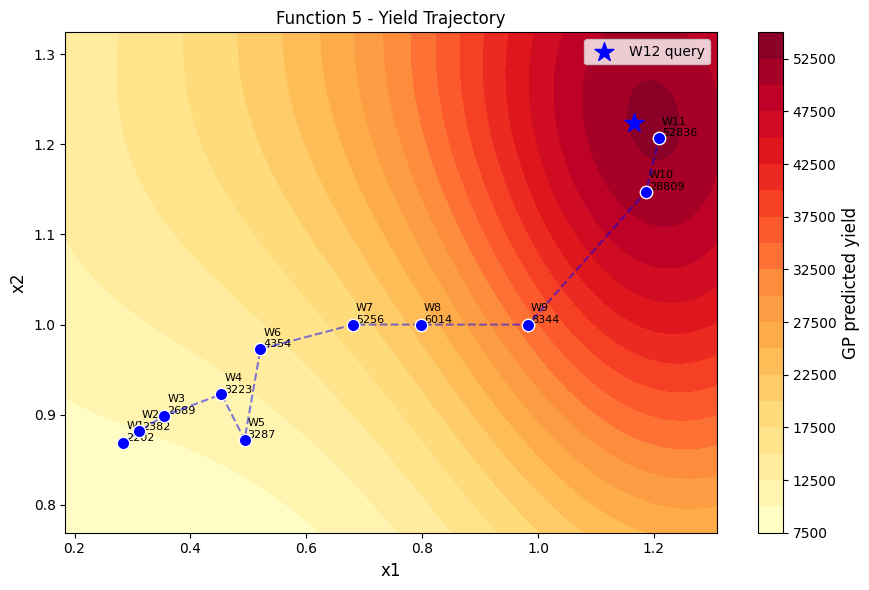

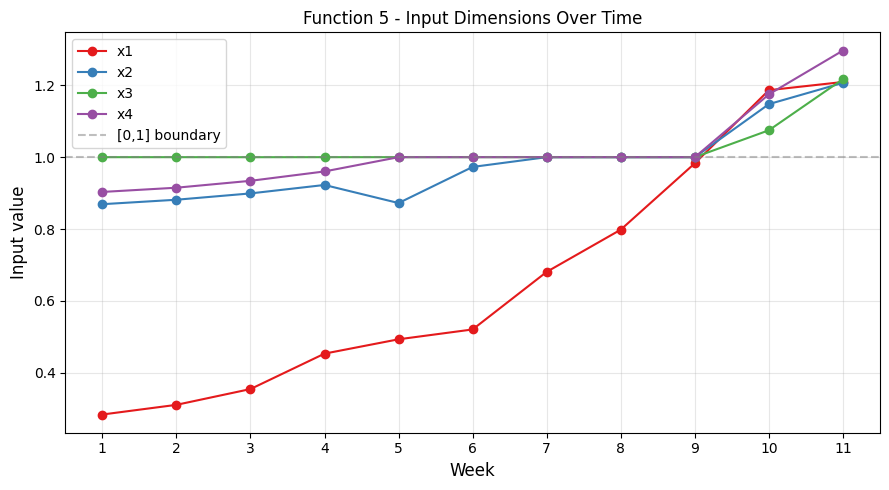

In [8]:
# =============================================================================
# FUNCTION 5 - Chemical Yield (4D)
# changes:
#   - added week 11 point, the surrogate has been proven to work properly
#   - added plot to show changes in input dimensions over time 
# =============================================================================

print("\n" + "=" * 60)
print("Function 5 - Week 12")
print("=" * 60)

f5_inputs  = np.load('../Data/function_5/initial_inputs.npy')
f5_outputs = np.load('../Data/function_5/initial_outputs.npy')

prev_queries = np.array([
    [0.284290, 0.869208, 0.999999, 0.903273],  # W1:  2201.83
    [0.311208, 0.881577, 0.999999, 0.915050],  # W2:  2381.54
    [0.355085, 0.899160, 0.999900, 0.934196],  # W3:  2689.15
    [0.453609, 0.922659, 0.999999, 0.960267],  # W4:  3223.24
    [0.493503, 0.872392, 0.999999, 0.999999],  # W5:  3286.99
    [0.520874, 0.972838, 0.999999, 0.999999],  # W6:  4354.08
    [0.681041, 0.999999, 0.999999, 0.999999],  # W7:  5255.70
    [0.798393, 0.999999, 0.999999, 0.999999],  # W8:  6014.32
    [0.982974, 0.999999, 0.999999, 0.999999],  # W9:  8343.74
    [1.186309, 1.147512, 1.074804, 1.174751],  # W10: 28809.34
    [1.209030, 1.206621, 1.216962, 1.296523],  # W11: 52835.61
])
prev_outputs = np.array([
    2201.834589108927,
    2381.536867607932,
    2689.1537294933396,
    3223.2410694936825,
    3286.9929500236235,
    4354.076520735467,
    5255.707269541747,
    6014.320020319561,
    8343.748023063841,
    28809.34147186407,
    52835.60848629657,
])

all_inputs  = np.vstack([f5_inputs, prev_queries])
all_outputs = np.hstack([f5_outputs, prev_outputs])

print(f"Total points: {len(all_outputs)}, best so far: {all_outputs.max():.2f}")

# SVR
input_scaler  = StandardScaler()
output_scaler = StandardScaler()
X_scaled = input_scaler.fit_transform(all_inputs)
Y_scaled = output_scaler.fit_transform(all_outputs.reshape(-1, 1)).ravel()

svr = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.01)
svr.fit(X_scaled, Y_scaled)

# GP on log-transformed outputs
y_log     = np.log1p(all_outputs)
kernel_gp = ConstantKernel(1.0, (0.001, 1000)) * Matern(length_scale=0.2, nu=2.5)
gp        = GaussianProcessRegressor(kernel=kernel_gp, n_restarts_optimizer=25, normalize_y=True)
gp.fit(all_inputs, y_log)

best_point = all_inputs[np.argmax(all_outputs)]
np.random.seed(42)

# local candidates -- no pinning, wide bounds
local = []
for _ in range(6000):
    c = best_point + np.random.normal(0, 0.05, 4)
    c = np.clip(c, 0, 5.0)
    local.append(c)

# directed candidates -- push all dimensions outward
directed = []
for _ in range(4000):
    c = best_point.copy()
    c[0] = np.clip(c[0] + abs(np.random.normal(0, 0.4)), 0, 5.0)
    c[1] = np.clip(c[1] + abs(np.random.normal(0, 0.3)), 0, 5.0)
    c[2] = np.clip(c[2] + abs(np.random.normal(0, 0.2)), 0, 5.0)
    c[3] = np.clip(c[3] + abs(np.random.normal(0, 0.2)), 0, 5.0)
    directed.append(c)

candidates = np.vstack([local, directed])

# SVR pre-filter: bypass for above-bounds candidates
X_cand_scaled = input_scaler.transform(candidates)
svr_preds_s   = svr.predict(X_cand_scaled)
svr_preds     = output_scaler.inverse_transform(svr_preds_s.reshape(-1, 1)).ravel()

above_bounds = (candidates > 1.0).any(axis=1)
in_bounds    = ~above_bounds

top_idx_ib   = np.argsort(svr_preds[in_bounds])[-5000:]
filtered_ib  = candidates[in_bounds][top_idx_ib]

filtered = np.vstack([candidates[above_bounds], filtered_ib])

print(f"Above-bounds candidates passed to GP: {above_bounds.sum()}")
print(f"In-bounds candidates passed to GP: {len(filtered_ib)}")

# GP mean argmax acquisition
mu_log, sigma_log = gp.predict(filtered, return_std=True)
best_idx = np.argmax(mu_log)
query = filtered[best_idx]

print(f"\nWeek 12 Query:       {format_query(query)}")
print(f"GP predicted yield: {np.expm1(mu_log[best_idx]):.2f}")
print(f"GP std (log scale): {sigma_log[best_idx]:.4f}")
svr_at_query = output_scaler.inverse_transform(
    svr.predict(input_scaler.transform(query.reshape(1, -1))).reshape(-1, 1)
).ravel()[0]
print(f"SVR prediction:     {svr_at_query:.2f}")

# --- Interpretability ---
print("\n--- GP vs SVR at historical queries ---")
print(f"{'Week':<6} {'Actual':>10} {'GP pred':>10} {'SVR pred':>10}")
for i, (q, actual) in enumerate(zip(prev_queries, prev_outputs)):
    gp_pred  = np.expm1(gp.predict(q.reshape(1, -1))[0])
    svr_pred = output_scaler.inverse_transform(
        svr.predict(input_scaler.transform(q.reshape(1, -1))).reshape(-1, 1)
    ).ravel()[0]
    print(f"W{i+1:<5} {actual:>10.1f} {gp_pred:>10.1f} {svr_pred:>10.1f}")

# --- Sweep all dimensions proportionally from best_point ---
print("\n--- Proportional scaling from best point ---")
print(f"{'scale':>6} {'GP yield':>10} {'GP std':>10} {'point'}")
for scale in [0.8, 0.9, 1.0, 1.05, 1.1, 1.2, 1.3, 1.5, 2.0]:
    test = (best_point * scale).reshape(1, -1)
    mu, sig = gp.predict(test, return_std=True)
    print(f"{scale:>6.2f} {np.expm1(mu[0]):>10.1f} {sig[0]:>10.4f}   {test[0].round(3)}")

# --- Plot: Contour with extended bounds ---
pad = 0.1
x1_min = min(prev_queries[:, 0].min(), query[0]) - 0.1
x1_max = max(prev_queries[:, 0].max(), query[0]) + pad
x2_min = min(prev_queries[:, 1].min(), query[1]) - pad
x2_max = max(prev_queries[:, 1].max(), query[1]) + pad

grid_n = 80
x1_range = np.linspace(x1_min, x1_max, grid_n)
x2_range = np.linspace(x2_min, x2_max, grid_n)
X1_g, X2_g = np.meshgrid(x1_range, x2_range)

grid_4d = np.column_stack([X1_g.ravel(), X2_g.ravel(),
                           np.full(grid_n**2, best_point[2]),
                           np.full(grid_n**2, best_point[3])])
mu_grid = np.expm1(gp.predict(grid_4d))
mu_grid = mu_grid.reshape(grid_n, grid_n)

fig, ax = plt.subplots(figsize=(9, 6))
cf = ax.contourf(X1_g, X2_g, mu_grid, levels=20, cmap='YlOrRd')
cbar = fig.colorbar(cf)
cbar.set_label('GP predicted yield', fontsize=12)

for i in range(len(prev_queries)):
    ax.scatter(prev_queries[i, 0], prev_queries[i, 1], c='blue',
               edgecolors='white', s=80, zorder=5)
    ax.annotate(f'W{i+1}\n{prev_outputs[i]:.0f}',
                (prev_queries[i, 0] + 0.005, prev_queries[i, 1] + 0.002), fontsize=8)
ax.plot(prev_queries[:, 0], prev_queries[:, 1], 'b--', alpha=0.5, zorder=4)
ax.scatter(query[0], query[1], marker='*', c='blue', s=200, zorder=10, label='W12 query')

ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_title('Function 5 - Yield Trajectory')
ax.legend()
fig.tight_layout()
plt.show()

# --- Plot: Dimension values over weeks ---
fig, ax = plt.subplots(figsize=(9, 5))
dim_labels = ['x1', 'x2', 'x3', 'x4']
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
weeks = np.arange(1, len(prev_queries) + 1)
for d in range(4):
    ax.plot(weeks, prev_queries[:, d], 'o-', color=colors[d],
            label=dim_labels[d], markersize=6)
ax.axhline(1.0, color='grey', linestyle='--', alpha=0.5, label='[0,1] boundary')
ax.set_xlabel('Week', fontsize=12)
ax.set_ylabel('Input value', fontsize=12)
ax.set_xticks(weeks)
ax.set_title('Function 5 - Input Dimensions Over Time')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Function 6 - week 12


Function 6 - Week 12
Total observations: 31, best so far: -0.2386

Stage 1: 5000 global candidates
Stage 2: 5000 local candidates (50 anchors × 100 each, radius=0.05)
Total:   10000 candidates

Week 12 Query (SVR): 0.404552-0.351640-0.659344-0.864379-0.045404
  Predicted value: -0.2169
  Source: Stage 2 (refined)


  0%|          | 0/31 [00:00<?, ?it/s]

/var/folders/7f/y1qhdsm97gb_hwv_0594n2s40000gn/T/ipykernel_18272/3694599798.py:156: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, all_inputs,


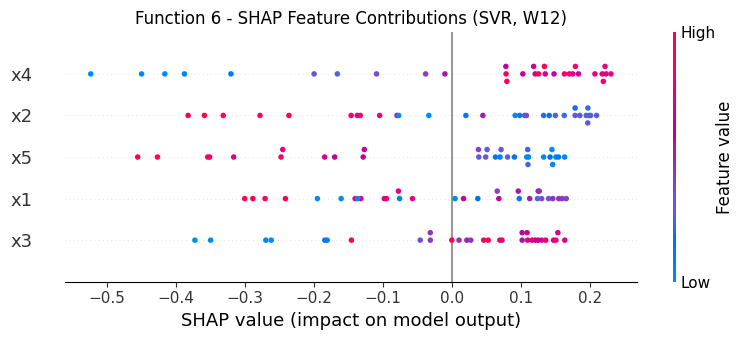

In [9]:
# =============================================================================
# FUNCTION 6 - Cake Recipe (5D)
# changes:
#   - reverted to w10 pipeline (best result: -0.239) 
#   - removed bootstrap UCB from w11 since it returned worse result. 
#   - updated SVR hyparameters based on diagnostic LOO grid on 31 points
#       from (g=0.1, C=50, e=0.001) to (g=0.15, C=50, e=0.005) 
#       top5_bias for g=0.15 is +0.002 versus +0.011 for g=0.1 (5× improvement in calibration)
# =============================================================================

print("\n" + "=" * 60)
print("Function 6 - Week 12")
print("=" * 60)

f6_inputs  = np.load('../Data/function_6/initial_inputs.npy')
f6_outputs = np.load('../Data/function_6/initial_outputs.npy')

prev_queries = np.array([
    [0.201818, 0.220639, 0.476414, 0.867793, 0.023115],  # W1:  -0.792
    [0.457382, 0.349799, 0.529520, 0.691032, 0.192589],  # W2:  -0.362
    [0.503404, 0.328861, 0.662838, 0.995031, 0.025514],  # W3:  -0.368
    [0.484266, 0.300747, 0.678836, 0.776480, 0.244496],  # W4:  -0.315
    [0.341066, 0.113474, 0.924694, 0.877339, 0.257942],  # W5:  -0.829
    [0.408506, 0.262542, 0.745611, 0.998966, 0.244739],  # W6:  -0.563
    [0.896209, 0.283983, 0.594508, 0.806739, 0.008612],  # W7:  -0.764
    [0.482908, 0.318128, 0.672147, 0.855190, 0.203478],  # W8:  -0.294 (2nd best)
    [0.527875, 0.386935, 0.580127, 0.788560, 0.032052],  # W9:  -0.329
    [0.501734, 0.353960, 0.724619, 0.834439, 0.116873],  # W10: -0.239 (best)
    [0.562063, 0.403283, 0.756503, 0.794358, 0.134931],  # W11: -0.380
])
prev_outputs = np.array([
    -0.792246,
    -0.361637,
    -0.367626,
    -0.314817,
    -0.828981,
    -0.5633934601648388,
    -0.764298611557724,
    -0.29468304435774073,
    -0.3284779356695814,
    -0.23855214682739972,
    -0.3807783612983387,
])

all_inputs  = np.vstack([f6_inputs, prev_queries])
all_outputs = np.hstack([f6_outputs, prev_outputs])

print(f"Total observations: {all_inputs.shape[0]}, best so far: {all_outputs.max():.4f}")

# --- SVR surrogate (hyperparams tuned for top-point bias) ---
svr = Pipeline([('scl', StandardScaler()), ('svr', SVR(kernel='rbf', C=50, gamma=0.15, epsilon=0.005))])
svr.fit(all_inputs, all_outputs)

# --- Two-stage candidate refinement ---
space      = Space([(0.0, 1.0)] * 5)
lhs        = Lhs(criterion="maximin", iterations=100)

# Stage 1: global LHS
np.random.seed(42)
stage1 = np.array(lhs.generate(space.dimensions, 5000))
stage1_preds = svr.predict(stage1)

# Stage 2: local refinement around top-K from stage 1
top_k = 50
top_k_idx = np.argsort(stage1_preds)[-top_k:]
top_k_points = stage1[top_k_idx]

radius = 0.05
stage2 = []
for point in top_k_points:
    local = point + np.random.uniform(-radius, radius, size=(100, 5))
    local = np.clip(local, 0, 1)
    stage2.append(local)
stage2 = np.vstack(stage2)

# Combine and score
all_candidates = np.vstack([stage1, stage2])
all_preds = svr.predict(all_candidates)
best_index = np.argmax(all_preds)
query = all_candidates[best_index]

# Report source
source = "Stage 1 (global)" if best_index < len(stage1) else "Stage 2 (refined)"

print(f"\nStage 1: {len(stage1)} global candidates")
print(f"Stage 2: {len(stage2)} local candidates ({top_k} anchors × 100 each, radius={radius})")
print(f"Total:   {len(all_candidates)} candidates")

print(f"\nWeek 12 Query (SVR): {format_query(query)}")
print(f"  Predicted value: {all_preds[best_index]:.4f}")
print(f"  Source: {source}")

# # --- Diagnostic ---
# # SVR hyperparameter grid scored on top-point bias (31 points)

# loo = LeaveOneOut()
# top5_idx = np.argsort(all_outputs)[-5:]

# gammas   = [0.05, 0.08, 0.1, 0.15, 0.2]
# Cs       = [10, 20, 50, 100]
# epsilons = [0.001, 0.005, 0.01, 0.02, 0.05]

# results = []

# for g in gammas:
#     for c in Cs:
#         for e in epsilons:
#             loo_preds = np.zeros(len(all_outputs))
#             for train_idx, test_idx in loo.split(all_inputs):
#                 pipe = Pipeline([('scl', StandardScaler()), ('svr', SVR(kernel='rbf', C=c, gamma=g, epsilon=e))])
#                 pipe.fit(all_inputs[train_idx], all_outputs[train_idx])
#                 loo_preds[test_idx] = pipe.predict(all_inputs[test_idx].reshape(1, -1))[0]

#             errors = all_outputs - loo_preds
#             mae = np.mean(np.abs(errors))
#             ss_res = np.sum(errors**2)
#             ss_tot = np.sum((all_outputs - all_outputs.mean())**2)
#             r2 = 1 - ss_res / ss_tot

#             top5_bias = errors[top5_idx].mean()
#             top5_mae = np.abs(errors[top5_idx]).mean()

#             results.append({
#                 'g': g, 'C': c, 'e': e,
#                 'r2': r2, 'mae': mae,
#                 'top5_bias': top5_bias, 'top5_mae': top5_mae
#             })

# passed = [r for r in results if r['r2'] >= 0.75]

# print(f"\n{'='*70}")
# print(f"SVR Grid: {len(results)} configs tested, {len(passed)} passed R2≥0.75")
# print(f"{'='*70}")

# passed.sort(key=lambda r: abs(r['top5_bias']))

# print(f"\n{'config':<22} {'R²':>6} {'MAE':>6} {'top5_bias':>10} {'top5_MAE':>9}")
# print("-" * 57)
# for r in passed[:30]:
#     label = f"g={r['g']} C={r['C']} e={r['e']}"
#     print(f"{label:<22} {r['r2']:>6.3f} {r['mae']:>6.3f} {r['top5_bias']:>+10.4f} {r['top5_mae']:>9.4f}")

# print("\n --- w10 config for reference ---")
# w10 = [r for r in results if r['g']==0.1 and r['C']==50 and r['e']==0.001]
# if w10:
#     r = w10[0]
#     print(f"g=0.1 C=50 e=0.001    R2={r['r2']:.3f}  top5_bias={r['top5_bias']:+.4f}  top5_MAE={r['top5_mae']:.4f}")

# --- Interpretability: SHAP on SVR (actual surrogate) ---
np.random.seed(42)
background  = all_inputs[np.random.choice(len(all_inputs), size=20, replace=False)]
explainer   = shap.KernelExplainer(svr.predict, background)
shap_values = explainer.shap_values(all_inputs, nsamples=100)

plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, all_inputs,
                  feature_names=[f'x{i+1}' for i in range(5)], show=False)
plt.title('Function 6 - SHAP Feature Contributions (SVR, W12)')
plt.tight_layout()
plt.show()

# Function 7 - week 12


Function 7 - Week 12
Total points: 41, best: 2.8536

Step 1a: Full-dataset Random Forest

Full-dataset RF importance:
  HP1: 0.717
  HP2: 0.121
  HP3: 0.032
  HP4: 0.026
  HP5: 0.029
  HP6: 0.075

Step 1b: Filtered Random Forest + SHAP (HP1 < 0.1 subset)
Points with HP1 < 0.1: 15
Output range in subset: 0.008 to 2.854

Filtered RF importance:
  HP1: 0.075  (was 0.717 in full dataset) ***
  HP2: 0.586  (was 0.121 in full dataset) ***
  HP3: 0.056  (was 0.032 in full dataset) 
  HP4: 0.076  (was 0.026 in full dataset) 
  HP5: 0.091  (was 0.029 in full dataset) 
  HP6: 0.117  (was 0.075 in full dataset) 

Permutation vs impurity importance (full dataset):
  Feature    Impurity  Permutation   Perm std
  HP1           0.717        1.240      0.202
  HP2           0.121        0.131      0.033
  HP3           0.032        0.019      0.006
  HP4           0.026        0.017      0.002
  HP5           0.029        0.023      0.005
  HP6           0.075        0.060      0.012

Permutation vs 

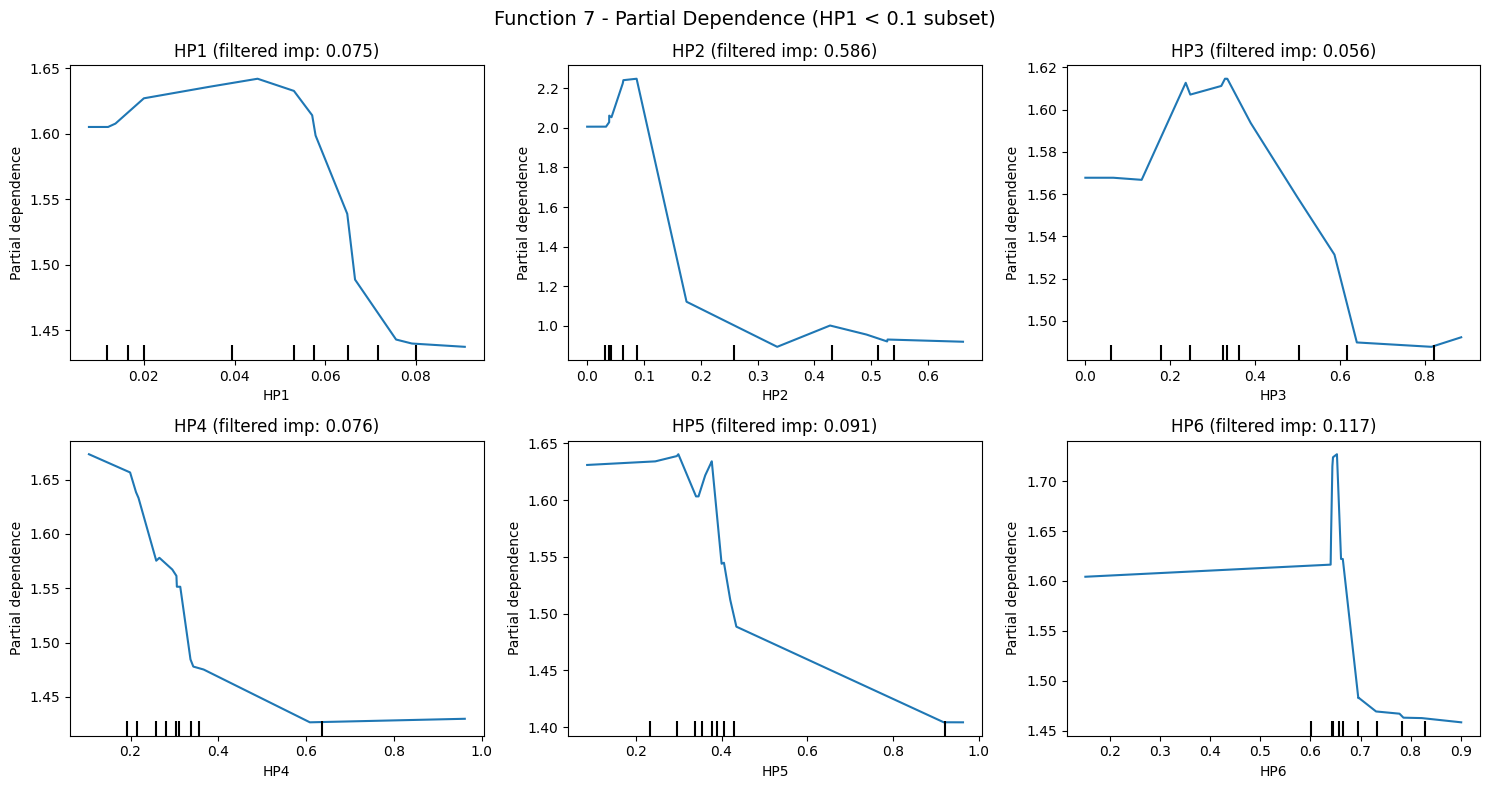

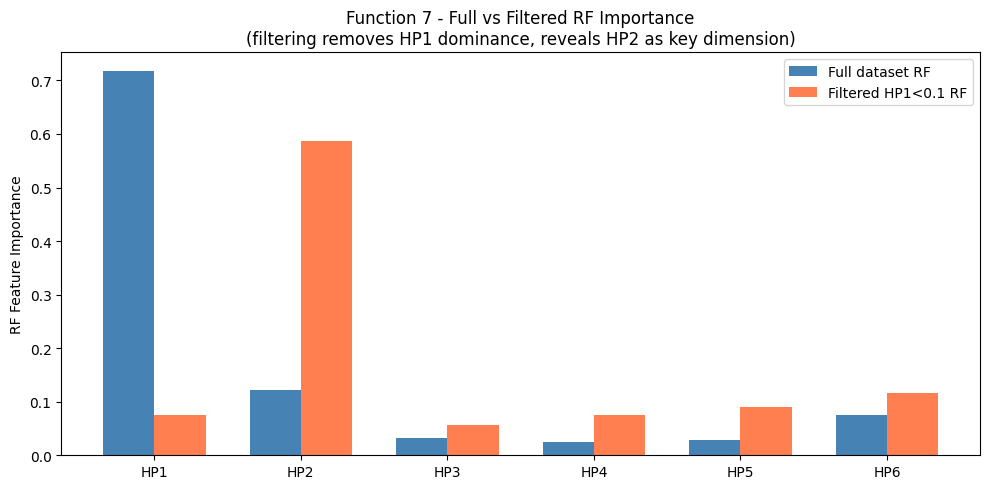

At W10: RF=2.7863 + GP_resid=0.0700 = 2.8563 (std=0.0202)
LOO MAE: 0.1329
LOO bias: -0.0737
Coverage (within 2std): 0.98  (should be ~0.95)

LOO at top-5 points:
  actual=2.106  error=-0.1281  covered=True
  actual=2.557  error=-0.0654  covered=True
  actual=2.602  error=+0.1457  covered=True
  actual=2.851  error=+0.0009  covered=True
  actual=2.854  error=+0.0490  covered=True

GP posterior at top-5 points:
  W9: actual=2.106  pred=2.108  std=0.0194
  W8: actual=2.557  pred=2.555  std=0.0198
  W3: actual=2.602  pred=2.598  std=0.0204
  W11: actual=2.851  pred=2.856  std=0.0202
  W10: actual=2.854  pred=2.844  std=0.0192

GP posterior at top-5:
  W9: actual=2.106  pred=2.108  std=0.0194  error=+0.002
  W8: actual=2.557  pred=2.555  std=0.0198  error=-0.002
  W3: actual=2.602  pred=2.598  std=0.0204  error=-0.004
  W11: actual=2.851  pred=2.856  std=0.0202  error=+0.005
  W10: actual=2.854  pred=2.844  std=0.0192  error=-0.009

Residual correlation with features (all weekly queries):
 

In [10]:
# =============================================================================
# FUNCTION 7 - ML Hyperparameters (6D)
# changes:
#   - added W11 to LHS candidate generation around best points previously only W10/W3/W8
#   - diagnostics switched from rf_full to rf_filtered for consistency
#   - kept residual GP (rf_filtered base + GP on residuals)
#   - GP posterior errors at top-5 all under 0.01 and residual correlations near zero
# =============================================================================

print("\n" + "=" * 60)
print("Function 7 - Week 12")
print("=" * 60)

f7_inputs  = np.load('../Data/function_7/initial_inputs.npy')
f7_outputs = np.load('../Data/function_7/initial_outputs.npy')

prev_queries = np.array([
    [0.045091, 0.528666, 0.329265, 0.105350, 0.434671, 0.641164],  # W1:  1.051
    [0.034389, 0.427542, 0.236649, 0.342956, 0.405706, 0.695527],  # W2:  1.653
    [0.020000, 0.062635, 0.587368, 0.313225, 0.362008, 0.664539],  # W3:  2.602 
    [0.012096, 0.033240, 0.640160, 0.336533, 0.245422, 0.901043],  # W4:  1.509
    [0.007872, 0.174935, 0.499616, 0.265730, 0.340533, 0.150339],  # W5:  0.383
    [0.020000, 0.000000, 0.000000, 0.212520, 0.346351, 0.696182],  # W6:  1.790
    [0.079160, 0.042812, 0.886277, 0.366485, 0.400229, 0.661016],  # W7:  1.429
    [0.057146, 0.038834, 0.320530, 0.305527, 0.377308, 0.643734],  # W8:  2.556
    [0.013721, 0.038746, 0.389878, 0.199046, 0.377306, 0.785650],  # W9:  2.106
    [0.064888, 0.063754, 0.333308, 0.295138, 0.295698, 0.644981],  # W10: 2.853 (best)
    [0.053115, 0.087040, 0.334801, 0.304509, 0.299321, 0.652840],  # W11: 2.850 (2nd best)
])
prev_outputs = np.array([
    1.0510006614196026, 
    1.6531363312716738, 
    2.6016443512251484,
    1.5087286481808686, 
    0.3832671270292543, 
    1.789927976010441,
    1.428502150382287,
    2.5567422716339334,
    2.106393447839423,
    2.8536051693908164,
    2.850996935426537,
])

all_inputs  = np.vstack([f7_inputs, prev_queries])
all_outputs = np.hstack([f7_outputs, prev_outputs])

print(f"Total points: {len(all_outputs)}, best: {all_outputs.max():.4f}")
        
feature_names = [f"HP{i+1}" for i in range(6)]

# --- Step 1a: Full-dataset Random Forest
print("\nStep 1a: Full-dataset Random Forest")
rf_full = RandomForestRegressor(n_estimators=200, random_state=42)
rf_full.fit(all_inputs, all_outputs)

print("\nFull-dataset RF importance:")
for name, imp in zip(feature_names, rf_full.feature_importances_):
    print(f"  {name}: {imp:.3f}")

# --- Step 1b: Filtered RF (HP1 < threshold subset)
# returned to 0.1 threshold
hp1_threshold = 0.1
print(f"\nStep 1b: Filtered Random Forest + SHAP (HP1 < {hp1_threshold} subset)")
hp1_mask = all_inputs[:, 0] < hp1_threshold
filtered_inputs  = all_inputs[hp1_mask]
filtered_outputs = all_outputs[hp1_mask]

print(f"Points with HP1 < {hp1_threshold}: {hp1_mask.sum()}")
print(f"Output range in subset: {filtered_outputs.min():.3f} to {filtered_outputs.max():.3f}")

rf_filtered = RandomForestRegressor(n_estimators=200, random_state=42)
rf_filtered.fit(filtered_inputs, filtered_outputs)

print("\nFiltered RF importance:")
for name, imp_full, imp_filt in zip(feature_names, rf_full.feature_importances_, rf_filtered.feature_importances_):
    change = "***" if abs(imp_filt - imp_full) > 0.1 else ""
    print(f"  {name}: {imp_filt:.3f}  (was {imp_full:.3f} in full dataset) {change}")

# Permutation importance validation (both RFs)
from sklearn.inspection import permutation_importance

print("\nPermutation vs impurity importance (full dataset):")
perm_full = permutation_importance(rf_full, all_inputs, all_outputs,
                                    n_repeats=30, random_state=42)
print(f"  {'Feature':<8} {'Impurity':>10} {'Permutation':>12} {'Perm std':>10}")
for i, name in enumerate(feature_names):
    print(f"  {name:<8} {rf_full.feature_importances_[i]:>10.3f} "
          f"{perm_full.importances_mean[i]:>12.3f} {perm_full.importances_std[i]:>10.3f}")

print("\nPermutation vs impurity importance (filtered HP1 < 0.1):")
perm_filt = permutation_importance(rf_filtered, filtered_inputs, filtered_outputs,
                                    n_repeats=30, random_state=42)
print(f"  {'Feature':<8} {'Impurity':>10} {'Permutation':>12} {'Perm std':>10}")
for i, name in enumerate(feature_names):
    print(f"  {name:<8} {rf_filtered.feature_importances_[i]:>10.3f} "
          f"{perm_filt.importances_mean[i]:>12.3f} {perm_filt.importances_std[i]:>10.3f}")

# SHAP on filtered RF (diagnostic)
explainer_filtered = shap.TreeExplainer(rf_filtered)
shap_filtered = explainer_filtered.shap_values(filtered_inputs)

print("\nSHAP analysis (filtered RF, diagnostic):")
print(f"  {'Feature':<8} {'|SHAP|':>8} {'Mean SHAP':>10}")
for name, abs_s, mean_s in zip(feature_names, np.abs(shap_filtered).mean(axis=0), shap_filtered.mean(axis=0)):
    print(f"  {name:<8} {abs_s:>8.3f} {mean_s:>+10.3f}")


# --- Step 2: Fit GP first, then generate candidates ---
print("\nStep 2: Fit Residual GP")

rf_base_train = rf_filtered.predict(all_inputs)  # compute residuals on all inputs not filtered
residuals = all_outputs - rf_base_train
print(f"Residual range: [{residuals.min():.4f}, {residuals.max():.4f}]")
print(f"Residual at W10: {all_outputs[-1] - rf_base_train[-1]:.4f}")
print(f"Residual std: {residuals.std():.4f}")


kernel = ConstantKernel(1.0, (0.01, 10.0)) * Matern(
    length_scale=[0.3] * 6,
    length_scale_bounds=(0.05, 5.0),
    nu=2.5,
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20,
    normalize_y=True,
    alpha=1e-3,                
)
gp.fit(all_inputs, residuals)


# Extract lengthscales from fitted kernel
for key, val in gp.kernel_.get_params().items():
    if 'length_scale' in key and 'bounds' not in key:
        if isinstance(val, np.ndarray) and len(val) == 6:
            fitted_ls = val

print(f"Fitted lengthscales: {fitted_ls}")

# --- Step 3: LHS Candidate Generation with Exclusion Zones ---
print("\nStep 3: LHS Candidate Generation")

# top 4 points
w10 = np.array([0.064888, 0.063754, 0.333308, 0.295138, 0.295698, 0.644981])
w11 = np.array([0.053115, 0.087040, 0.334801, 0.304509, 0.299321, 0.652840])
w3  = np.array([0.020000, 0.062635, 0.587368, 0.313225, 0.362008, 0.664539])
w8  = np.array([0.057146, 0.038834, 0.320530, 0.305527, 0.377308, 0.643734])

top4 = np.vstack([w10, w11, w3, w8])
radius = np.ptp(top4, axis=0)
radius = np.maximum(radius, 0.02)

sampler = LatinHypercube(d=6, seed=42)
cands_w10 = w10 - radius + 2 * radius * sampler.random(n=750)
cands_w11 = w11 - radius + 2 * radius * sampler.random(n=750)
cands_w3  = w3  - radius + 2 * radius * sampler.random(n=250)
cands_w8  = w8  - radius + 2 * radius * sampler.random(n=250)
candidates = np.clip(np.vstack([cands_w10, cands_w11, cands_w3, cands_w8]), 0, 1)


print(f"\nFeature ranges in candidate pool:")
for i, name in enumerate(feature_names):
    print(f"  {name}: [{candidates[:, i].min():.3f}, {candidates[:, i].max():.3f}]  mean={candidates[:, i].mean():.3f}")

# --- Step 4: Score candidates with Residual GP + EI ---
print("\nStep 4: Residual GP + EI")

rf_base_cand = rf_filtered.predict(candidates)
mu_resid, sigma_resid = gp.predict(candidates, return_std=True)
mu_total = rf_base_cand + mu_resid
best_so_far = all_outputs.max()

# --- EI 
xi = 0.01
z = (mu_total - best_so_far - xi) / (sigma_resid + 1e-10)
ei = (mu_total - best_so_far - xi) * norm.cdf(z) + sigma_resid * norm.pdf(z)
ei[sigma_resid < 1e-10] = 0.0
best_idx = np.argmax(ei)

best_candidate = candidates[best_idx]

print(f"\nWeek 12 Query: {format_query(best_candidate)}")
print(f"RF base prediction     : {rf_base_cand[best_idx]:.4f}")
print(f"GP residual prediction : {mu_resid[best_idx]:.4f}")
print(f"Total predicted Y      : {mu_total[best_idx]:.4f}")
print(f"GP residual std        : {sigma_resid[best_idx]:.4f}")
print(f"EI score               : {ei[best_idx]:.6f}")
print(f"Best so far            : {best_so_far:.4f}")

# --- Interpretability: Partial dependence on filtered RF ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    PartialDependenceDisplay.from_estimator(rf_filtered, filtered_inputs,
                                             features=[i],
                                             feature_names=feature_names, ax=ax)
    ax.set_title(f'{feature_names[i]} (filtered imp: {rf_filtered.feature_importances_[i]:.3f})')
plt.suptitle('Function 7 - Partial Dependence (HP1 < 0.1 subset)', fontsize=14)
plt.tight_layout()
plt.show()

# --- Interpretability: full vs filtered importance comparison ---
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(6)
width_bar = 0.35
ax.bar(x_pos - width_bar/2, rf_full.feature_importances_, width_bar, label='Full dataset RF', color='steelblue')
ax.bar(x_pos + width_bar/2, rf_filtered.feature_importances_, width_bar, label='Filtered HP1<0.1 RF', color='coral')
ax.set_xticks(x_pos)
ax.set_xticklabels(feature_names)
ax.set_ylabel('RF Feature Importance')
ax.set_title('Function 7 - Full vs Filtered RF Importance\n(filtering removes HP1 dominance, reveals HP2 as key dimension)')
ax.legend()
plt.tight_layout()
plt.show()

# --- Diagnostics ---

# best point comparison
w10 = all_inputs[-1].reshape(1, -1)
w10_rf = rf_filtered.predict(w10)[0]
w10_mu, w10_std = gp.predict(w10, return_std=True)
print(f"At W10: RF={w10_rf:.4f} + GP_resid={w10_mu[0]:.4f} = {w10_rf+w10_mu[0]:.4f} (std={w10_std[0]:.4f})")

# LOO diagnostic
loo = LeaveOneOut()
errors = []
coverages = []

for train_idx, test_idx in loo.split(all_inputs):
    X_train, X_test = all_inputs[train_idx], all_inputs[test_idx]
    y_train, y_test = np.sqrt(all_outputs[train_idx]), np.sqrt(all_outputs[test_idx])
    
    gp_loo = GaussianProcessRegressor(
        kernel=kernel,
        alpha=1e-3,
        n_restarts_optimizer=5,
        normalize_y=True,
    )
    gp_loo.fit(X_train, y_train)
    
    mu_test, sig_test = gp_loo.predict(X_test, return_std=True)
    
    actual = y_test[0] ** 2
    pred = mu_test[0] ** 2
    error = actual - pred
    # was the true value within 2 std of the prediction?
    coverage = abs(y_test[0] - mu_test[0]) < 2 * sig_test[0]
    
    errors.append(error)
    coverages.append(coverage)

errors = np.array(errors)
print(f"LOO MAE: {np.abs(errors).mean():.4f}")
print(f"LOO bias: {errors.mean():+.4f}")
print(f"Coverage (within 2std): {np.mean(coverages):.2f}  (should be ~0.95)")

# coverage and errors at best points
print("\nLOO at top-5 points:")
for idx in np.argsort(all_outputs)[-5:]:
    print(f"  actual={all_outputs[idx]:.3f}  error={errors[idx]:+.4f}  "
          f"covered={coverages[idx]}")


# Check GP's confidence at W10 vs other top points
print("\nGP posterior at top-5 points:")
for idx in np.argsort(all_outputs)[-5:]:
    mu_p, sig_p = gp.predict(all_inputs[idx].reshape(1,-1), return_std=True)
    rf_p = rf_filtered.predict(all_inputs[idx].reshape(1,-1))[0]
    total_pred = rf_p + mu_p[0]
    source = "initial" if idx < len(f7_inputs) else f"W{idx - len(f7_inputs) + 1}"
    print(f"  {source}: actual={all_outputs[idx]:.3f}  pred={total_pred:.3f}  "
          f"std={sig_p[0]:.4f}")

print("\nGP posterior at top-5:")
for idx in np.argsort(all_outputs)[-5:]:
    mu_p, sig_p = gp.predict(all_inputs[idx].reshape(1,-1), return_std=True)
    rf_p = rf_filtered.predict(all_inputs[idx].reshape(1,-1))[0]
    total_pred = rf_p + mu_p[0]
    error = total_pred - all_outputs[idx]
    source = "initial" if idx < len(f7_inputs) else f"W{idx - len(f7_inputs) + 1}"
    print(f"  {source}: actual={all_outputs[idx]:.3f}  pred={total_pred:.3f}  "
          f"std={sig_p[0]:.4f}  error={error:+.3f}")

print("\nResidual correlation with features (all weekly queries):")
residuals_diag = []
for i in range(len(prev_queries)):
    mu_r, _ = gp.predict(prev_queries[i].reshape(1,-1), return_std=True)
    rf_r = rf_filtered.predict(prev_queries[i].reshape(1,-1))[0]
    total_r = rf_r + mu_r[0]
    residuals_diag.append(prev_outputs[i] - total_r)
residuals_diag = np.array(residuals_diag)

for dim in range(6):
    corr = np.corrcoef(prev_queries[:, dim], residuals_diag)[0, 1]
    print(f"  HP{dim+1}: correlation={corr:+.3f}")

w10 = all_inputs[-2]  # W10's index
print(f"\nrf_full at W10: {rf_full.predict(w10.reshape(1,-1))[0]:.4f}")
print(f"rf_filtered at W10: {rf_filtered.predict(w10.reshape(1,-1))[0]:.4f}")



# Function 8 - week 12


Function 8 - Week 12
Total points: 51, best: 9.9244
Training loss (final, weighted): 0.115638

Weighted LOO Calibration (hidden=48):
  mean |error|:        0.1715
  mean sigma:          0.2008
  ratio (error/sigma): 0.854
  kappa (adaptive):    0.85

Weighted Top-k LOO (output > 9.0):
  mean |error|:        0.1479
  mean sigma:          0.1484
  ratio (error/sigma): 0.997

  Per-point breakdown (top-k, weighted, sorted by ratio):
    point 47 (  W8): y=9.6741, |err|=0.0144, sigma=0.1464, ratio=0.098
    point 40 (  W1): y=9.6724, |err|=0.0191, sigma=0.1459, ratio=0.131
    point 39 (init): y=9.1830, |err|=0.0265, sigma=0.1332, ratio=0.199
    point 45 (  W6): y=9.6200, |err|=0.0318, sigma=0.1520, ratio=0.209
    point 48 (  W9): y=9.6526, |err|=0.0449, sigma=0.1469, ratio=0.305
    point 14 (init): y=9.5985, |err|=0.0566, sigma=0.1714, ratio=0.330
    point 41 (  W2): y=9.6264, |err|=0.0469, sigma=0.1356, ratio=0.346
    point 46 (  W7): y=9.5831, |err|=0.0921, sigma=0.1536, ratio=0.6

  0%|          | 0/51 [00:00<?, ?it/s]

/var/folders/7f/y1qhdsm97gb_hwv_0594n2s40000gn/T/ipykernel_18272/1622346700.py:197: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sc,


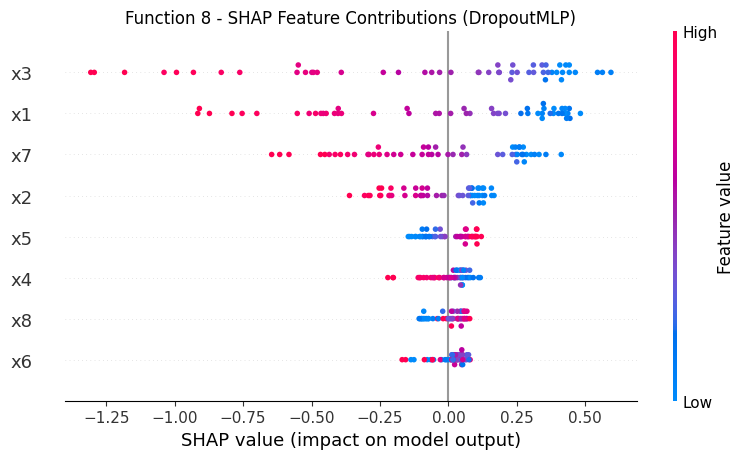


SHAP-derived importance (normalised):
  x1: 0.856
  x2: 0.307
  x3: 1.000
  x4: 0.136
  x5: 0.173
  x6: 0.108
  x7: 0.575
  x8: 0.115

mu   range: 4.198 to 9.813
sigma range: 0.060 to 0.896
kappa*sigma range: 0.051 to 0.765

Week 12 Query: 0.087230-0.285432-0.004252-0.058053-0.999415-0.643326-0.319191-0.894158
MC mu: 9.8068, sigma: 0.1729
UCB:   9.9545


In [12]:
# =============================================================================
# FUNCTION 8 - 8D Black-Box
# changes:
#   - kept week 10 & 11 surrogate: 
#        MLP with SiLU activation (hidden=48 dropout=0.25), weighted MSE with global LHS 50k 
#        top-k calibration improved from 0.915 to 0.997, global ratio is similar to w10/11 around 0.85 
#   - reduced kappa_base from 1.7 to 1.0
#   - removed redundant diagnostics (unweighted LOO, high-error initial points)
#   - updated top-k breakdown to be sorted by calibration ratio with week labels
# =============================================================================

print("\n" + "=" * 60)
print("Function 8 - Week 12")
print("=" * 60)

f8_inputs  = np.load('../Data/function_8/initial_inputs.npy')
f8_outputs = np.load('../Data/function_8/initial_outputs.npy')

prev_queries = np.array([
    [0.182943, 0.000000, 0.000000, 0.000000, 0.999999, 0.127124, 0.092403, 0.000000],  # W1:  9.672
    [0.022695, 0.000000, 0.274348, 0.000000, 0.999999, 0.127124, 0.028034, 0.000000],  # W2:  9.626
    [0.005086, 0.000000, 0.048567, 0.000000, 0.999999, 0.998962, 0.018674, 0.000000],  # W3:  9.546
    [0.000000, 0.000000, 0.012582, 0.000000, 0.999999, 0.000000, 0.066411, 0.000000],  # W4:  9.552
    [0.143046, 0.934478, 0.256793, 0.378273, 0.985471, 0.743394, 0.090143, 0.014829],  # W5:  9.146
    [0.060495, 0.027090, 0.006185, 0.132068, 0.160719, 0.354431, 0.001361, 0.931902],  # W6:  9.620
    [0.000000, 0.000000, 0.000000, 0.120009, 0.144817, 0.385066, 0.000000, 0.986589],  # W7:  9.583
    [0.134058, 0.010517, 0.000000, 0.000705, 0.991616, 0.110483, 0.084702, 0.012878],  # W8:  9.674 
    [0.167672, 0.021651, 0.000000, 0.000669, 0.988603, 0.107425, 0.054024, 0.014735],  # W9:  9.652
    [0.068646, 0.267399, 0.019682, 0.160065, 0.776599, 0.459921, 0.106417, 0.402908],  # W10: 9.924 (best)
    [0.033326, 0.138785, 0.153799, 0.515868, 0.796619, 0.640356, 0.018840, 0.702231],  # W11: 9.769 (2nd best)
])
prev_outputs = np.array([
    9.6723503773075, 
    9.6263579169495, 
    9.5463675507445,
    9.5519471979855, 
    9.1457303782294, 
    9.6199985919071,
    9.5831132283264,
    9.6740952800446,
    9.652595613866,
    9.9243596295041,
    9.7690362773434,
])

all_inputs  = np.vstack([f8_inputs, prev_queries])
all_outputs = np.hstack([f8_outputs, prev_outputs])

print(f"Total points: {len(all_outputs)}, best: {all_outputs.max():.4f}")

# scale inputs and outputs
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_sc = scaler_x.fit_transform(all_inputs)
Y_sc = scaler_y.fit_transform(all_outputs.reshape(-1, 1)).ravel()

X_tensor = torch.tensor(X_sc, dtype=torch.float32)
Y_tensor = torch.tensor(Y_sc, dtype=torch.float32).unsqueeze(1)

# MLP: hidden=48, dropout=0.25 
class DropoutMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        return self.net(x)

kappa_base = 1.0 # base kappa

# --- train final model (weighted loss, increased capacity) ---
# weight: high-scoring points matter more
weights = np.ones(len(all_outputs))
weights[all_outputs > 9.0] = 5.0
weights[all_outputs > 9.5] = 10.0
weight_tensor = torch.tensor(weights, dtype=torch.float32)

torch.manual_seed(42)
model     = DropoutMLP(input_dim=8, hidden_dim=48, dropout_rate=0.25)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)

model.train()
for epoch in range(1500):
    optimiser.zero_grad()
    pred = model(X_tensor)
    loss = (weight_tensor * (pred.squeeze() - Y_tensor.squeeze())**2).mean()
    loss.backward()
    optimiser.step()

print(f"Training loss (final, weighted): {loss.item():.6f}")

# --- Weighted LOO for comparison ---
loo_errors_w = []
loo_sigmas_w = []

for i in range(len(all_outputs)):
    X_train_loo = np.delete(all_inputs, i, axis=0)
    y_train_loo = np.delete(all_outputs, i)
    X_test_loo  = all_inputs[i:i+1]
    y_test_loo  = all_outputs[i]

    w_loo = np.ones(len(y_train_loo))
    w_loo[y_train_loo > 9.0] = 5.0
    w_loo[y_train_loo > 9.5] = 10.0
    w_loo_tensor = torch.tensor(w_loo, dtype=torch.float32)

    sx_loo = StandardScaler()
    sy_loo = StandardScaler()
    X_tr_sc_loo = sx_loo.fit_transform(X_train_loo)
    y_tr_sc_loo = sy_loo.fit_transform(y_train_loo.reshape(-1, 1)).ravel()
    X_te_sc_loo = sx_loo.transform(X_test_loo)

    X_tr_tensor = torch.tensor(X_tr_sc_loo, dtype=torch.float32)
    Y_tr_tensor = torch.tensor(y_tr_sc_loo, dtype=torch.float32).unsqueeze(1)
    X_te_tensor = torch.tensor(X_te_sc_loo, dtype=torch.float32)

    torch.manual_seed(42)
    model_loo     = DropoutMLP(input_dim=8, hidden_dim=48, dropout_rate=0.25)
    optimiser_loo = torch.optim.Adam(model_loo.parameters(), lr=1e-3)

    model_loo.train()
    for epoch in range(1500):
        optimiser_loo.zero_grad()
        pred_loo = model_loo(X_tr_tensor)
        loss_loo = (w_loo_tensor * (pred_loo.squeeze() - Y_tr_tensor.squeeze())**2).mean()
        loss_loo.backward()
        optimiser_loo.step()

    mu_sc_loo, sigma_sc_loo = mc_predict(model_loo, X_te_tensor, n_passes=100)
    mu_loo    = sy_loo.inverse_transform(mu_sc_loo.reshape(-1, 1)).ravel()[0]
    sigma_loo = np.atleast_1d(sigma_sc_loo)[0] * sy_loo.scale_[0]

    loo_errors_w.append(abs(mu_loo - y_test_loo))
    loo_sigmas_w.append(sigma_loo)

loo_errors_w = np.array(loo_errors_w)
loo_sigmas_w = np.array(loo_sigmas_w)

# --- weighted kappa calclation
cal_ratio_w = loo_errors_w.mean() / loo_sigmas_w.mean()
kappa_w     = kappa_base * cal_ratio_w

print(f"\nWeighted LOO Calibration (hidden=48):")
print(f"  mean |error|:        {loo_errors_w.mean():.4f}")
print(f"  mean sigma:          {loo_sigmas_w.mean():.4f}")
print(f"  ratio (error/sigma): {cal_ratio_w:.3f}")
print(f"  kappa (adaptive):    {kappa_w:.2f}")

# Top-k breakdown (weighted model)
top_k_mask_w = all_outputs > 9.0
top_k_errors_w = loo_errors_w[top_k_mask_w]
top_k_sigmas_w = loo_sigmas_w[top_k_mask_w]
top_k_cal_w    = top_k_errors_w.mean() / top_k_sigmas_w.mean()

print(f"\nWeighted Top-k LOO (output > 9.0):")
print(f"  mean |error|:        {top_k_errors_w.mean():.4f}")
print(f"  mean sigma:          {top_k_sigmas_w.mean():.4f}")
print(f"  ratio (error/sigma): {top_k_cal_w:.3f}")

# top points ranked from best to worst
print(f"\n  Per-point breakdown (top-k, weighted, sorted by ratio):")
top_k_indices_w = np.where(top_k_mask_w)[0]
# Sort by ratio (error/sigma), best first
ratios = [(idx, loo_errors_w[idx]/loo_sigmas_w[idx]) for idx in top_k_indices_w]
ratios.sort(key=lambda x: x[1])

n_initial = len(f8_outputs)
for idx, ratio in ratios:
    label = f"W{idx - n_initial + 1}" if idx >= n_initial else f"init"
    print(f"    point {idx:2d} ({label:>4s}): y={all_outputs[idx]:.4f}, "
          f"|err|={loo_errors_w[idx]:.4f}, sigma={loo_sigmas_w[idx]:.4f}, "
          f"ratio={ratio:.3f}")


# --- SHAP on the DropoutMLP ---
model.eval()

def mlp_predict(X_np):
    """Wrapper for SHAP -- takes numpy array, returns numpy predictions."""
    X_t = torch.tensor(X_np, dtype=torch.float32)
    with torch.no_grad():
        preds = model(X_t).squeeze().numpy()
    return np.atleast_1d(preds)

background = X_sc[np.random.choice(len(X_sc), size=20, replace=False)]
explainer  = shap.KernelExplainer(mlp_predict, background)
shap_values = explainer.shap_values(X_sc, nsamples=100)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sc,
                  feature_names=[f'x{i+1}' for i in range(8)], show=False)
plt.title('Function 8 - SHAP Feature Contributions (DropoutMLP)')
plt.tight_layout()
plt.show()

model.train()  # back to train mode for MC dropout

# --- SHAP importance for noise scaling ---
shap_importance = np.abs(shap_values).mean(axis=0)
shap_importance = shap_importance / shap_importance.max()

print("\nSHAP-derived importance (normalised):")
for i in range(8):
    print(f"  x{i+1}: {shap_importance[i]:.3f}")

# ------ LHS candiate pool
sampler = LatinHypercube(d=8, seed=43) # updated seed
pool = sampler.random(n=50000)

# scale and predict
pool_sc     = scaler_x.transform(pool)
pool_tensor = torch.tensor(pool_sc, dtype=torch.float32)

mu_sc, sigma_sc = mc_predict(model, pool_tensor, n_passes=100)

mu    = scaler_y.inverse_transform(mu_sc.reshape(-1, 1)).ravel()
sigma = sigma_sc * scaler_y.scale_[0]

# UCB with adaptive kappa
ucb      = mu + kappa_w * sigma
best_idx = np.argmax(ucb)
query    = pool[best_idx]

print(f"\nmu   range: {mu.min():.3f} to {mu.max():.3f}")
print(f"sigma range: {sigma.min():.3f} to {sigma.max():.3f}")
print(f"kappa*sigma range: {(kappa_w*sigma).min():.3f} to {(kappa_w*sigma).max():.3f}")

print(f"\nWeek 12 Query: {format_query(query)}")
print(f"MC mu: {mu[best_idx]:.4f}, sigma: {sigma[best_idx]:.4f}")
print(f"UCB:   {ucb[best_idx]:.4f}")